# Figure 3: Overview of training setup

## Package imports

In [1]:
# General imports
import glob
import json
import random
import sys
from typing import Optional, List, Dict, Any

# Data handling and visualization
import pandas as pd
import numpy as np
import evofr as ef
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
import seaborn as sns

from antigentools.utils import (
    get_deme_stats,
    get_outliers,
)
from antigentools.analysis import (
    get_filtered_growth_rates_df,
    filter_growth_rates
)

from antigentools.plot import (
    plot_analysis_window_with_variant_counts,
    plot_growth_rate_dynamics,
    plot_observed_cases, 
    get_analysis_window, # Move this to utils.py?
    print_window_stats, # Move this to utils.py?
)

# Publication styling imports
from antigentools.publication_style import (
    apply_publication_styling_to_figure,
    style_figure_for_publication,
    PublicationFigureStyler,
    publication_style
)

# Static variables for consistent growth rate filtering across the notebook
CONNECT_GAPS = True # Whether to connect gaps in the growth rate data when plotting
MIN_SEGMENT_LENGTH = 3 # Minimum segment length to trust growth rate calculations
MIN_SEQUENCE_COUNT = 10  # Minimum smoothed sequence count to continue with growth rate calculations
MIN_VARIANT_FREQUENCY = 0.01  # Minimum variant frequency to trust growth rate to consider growth rate calculations
EPSILON = 1e-3  # Tolerance threshold for overestimation rate calculations

# NEW: Sequence count threshold filter (set to None to disable filtering)
MIN_TOTAL_SEQUENCES = 300  # e.g., 750 to require at least 750 total sequences per window
CONVERGENCE_THRESHOLD = 0.5  # Threshold for convergence diagnostics
build = "flu-simulated-150k-samples"
print(f"Analysis configuration for build: {build}:")
print(f"  MIN_TOTAL_SEQUENCES filter: {MIN_TOTAL_SEQUENCES}")
print(f"  MIN_SEQUENCE_COUNT per variant: {MIN_SEQUENCE_COUNT}")
print(f"  MIN_VARIANT_FREQUENCY: {MIN_VARIANT_FREQUENCY}")
print(f"  EPSILON (overestimation tolerance): {EPSILON}")

/Users/zthornto/miniforge3/envs/antigen/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Analysis configuration for build: flu-simulated-150k-samples:
  MIN_TOTAL_SEQUENCES filter: 300
  MIN_SEQUENCE_COUNT per variant: 10
  MIN_VARIANT_FREQUENCY: 0.01
  EPSILON (overestimation tolerance): 0.001


In [2]:
# Plotting configuration 
# Small fonts for dense plots
small_fonts = {
    'title_fontsize': 14,
    'label_fontsize': 12,
    'tick_labelsize': 10,
    'legend_fontsize': 10,
    'legend_title_fontsize': 12
 }

# Large fonts for presentations
presentation_fonts = {
    'title_fontsize': 28,
    'label_fontsize': 20,
    'tick_labelsize': 16,
    'legend_fontsize': 16,
    'legend_title_fontsize': 18
}

# Default/medium fonts
default_fonts = {
    'title_fontsize': 18,
    'label_fontsize': 14,
    'tick_labelsize': 12,
    'legend_fontsize': 12,
    'legend_title_fontsize': 14
}

# Variant color map
color_map_path = f"../data/{build}/auspice/variant_color_map.tsv"
color_map_df = pd.read_csv(color_map_path, sep="\t")
# Create a color map dictionary from the color_map_df
color_map = dict(zip(color_map_df['TRAIT_VALUE'], color_map_df['HEX_CODE']))
# String color map for plotting
color_map_str = {str(k): v for k, v in color_map.items()}
print(f"Created color map with {len(color_map)} entries")
print(f"Sample: {list(color_map.items())[:5]}")

Created color map with 30 entries
Sample: [(0, '#5400ff'), (1, '#0074ff'), (2, '#ee00ff'), (3, '#00ff27'), (4, '#08ff00')]


In [3]:
fitness_path = f"../data/{build}/antigen-outputs/pruned_variant_fitness.csv"
truth_set_dir = f"../data/{build}/time-stamped/truth/"
truth_seqs_df = pd.read_csv(f"{truth_set_dir}/seq_counts.tsv", sep="\t")
truth_cases_df = pd.read_csv(f"{truth_set_dir}/case_counts.tsv", sep="\t")
fitness_df = pd.read_csv(fitness_path)

## Window setup

#### Examples of interesting forecasting windows

Total cases: 30952.0
Total sequences: 3865.0
Variant counts: [3248.   11.   17.  589.]


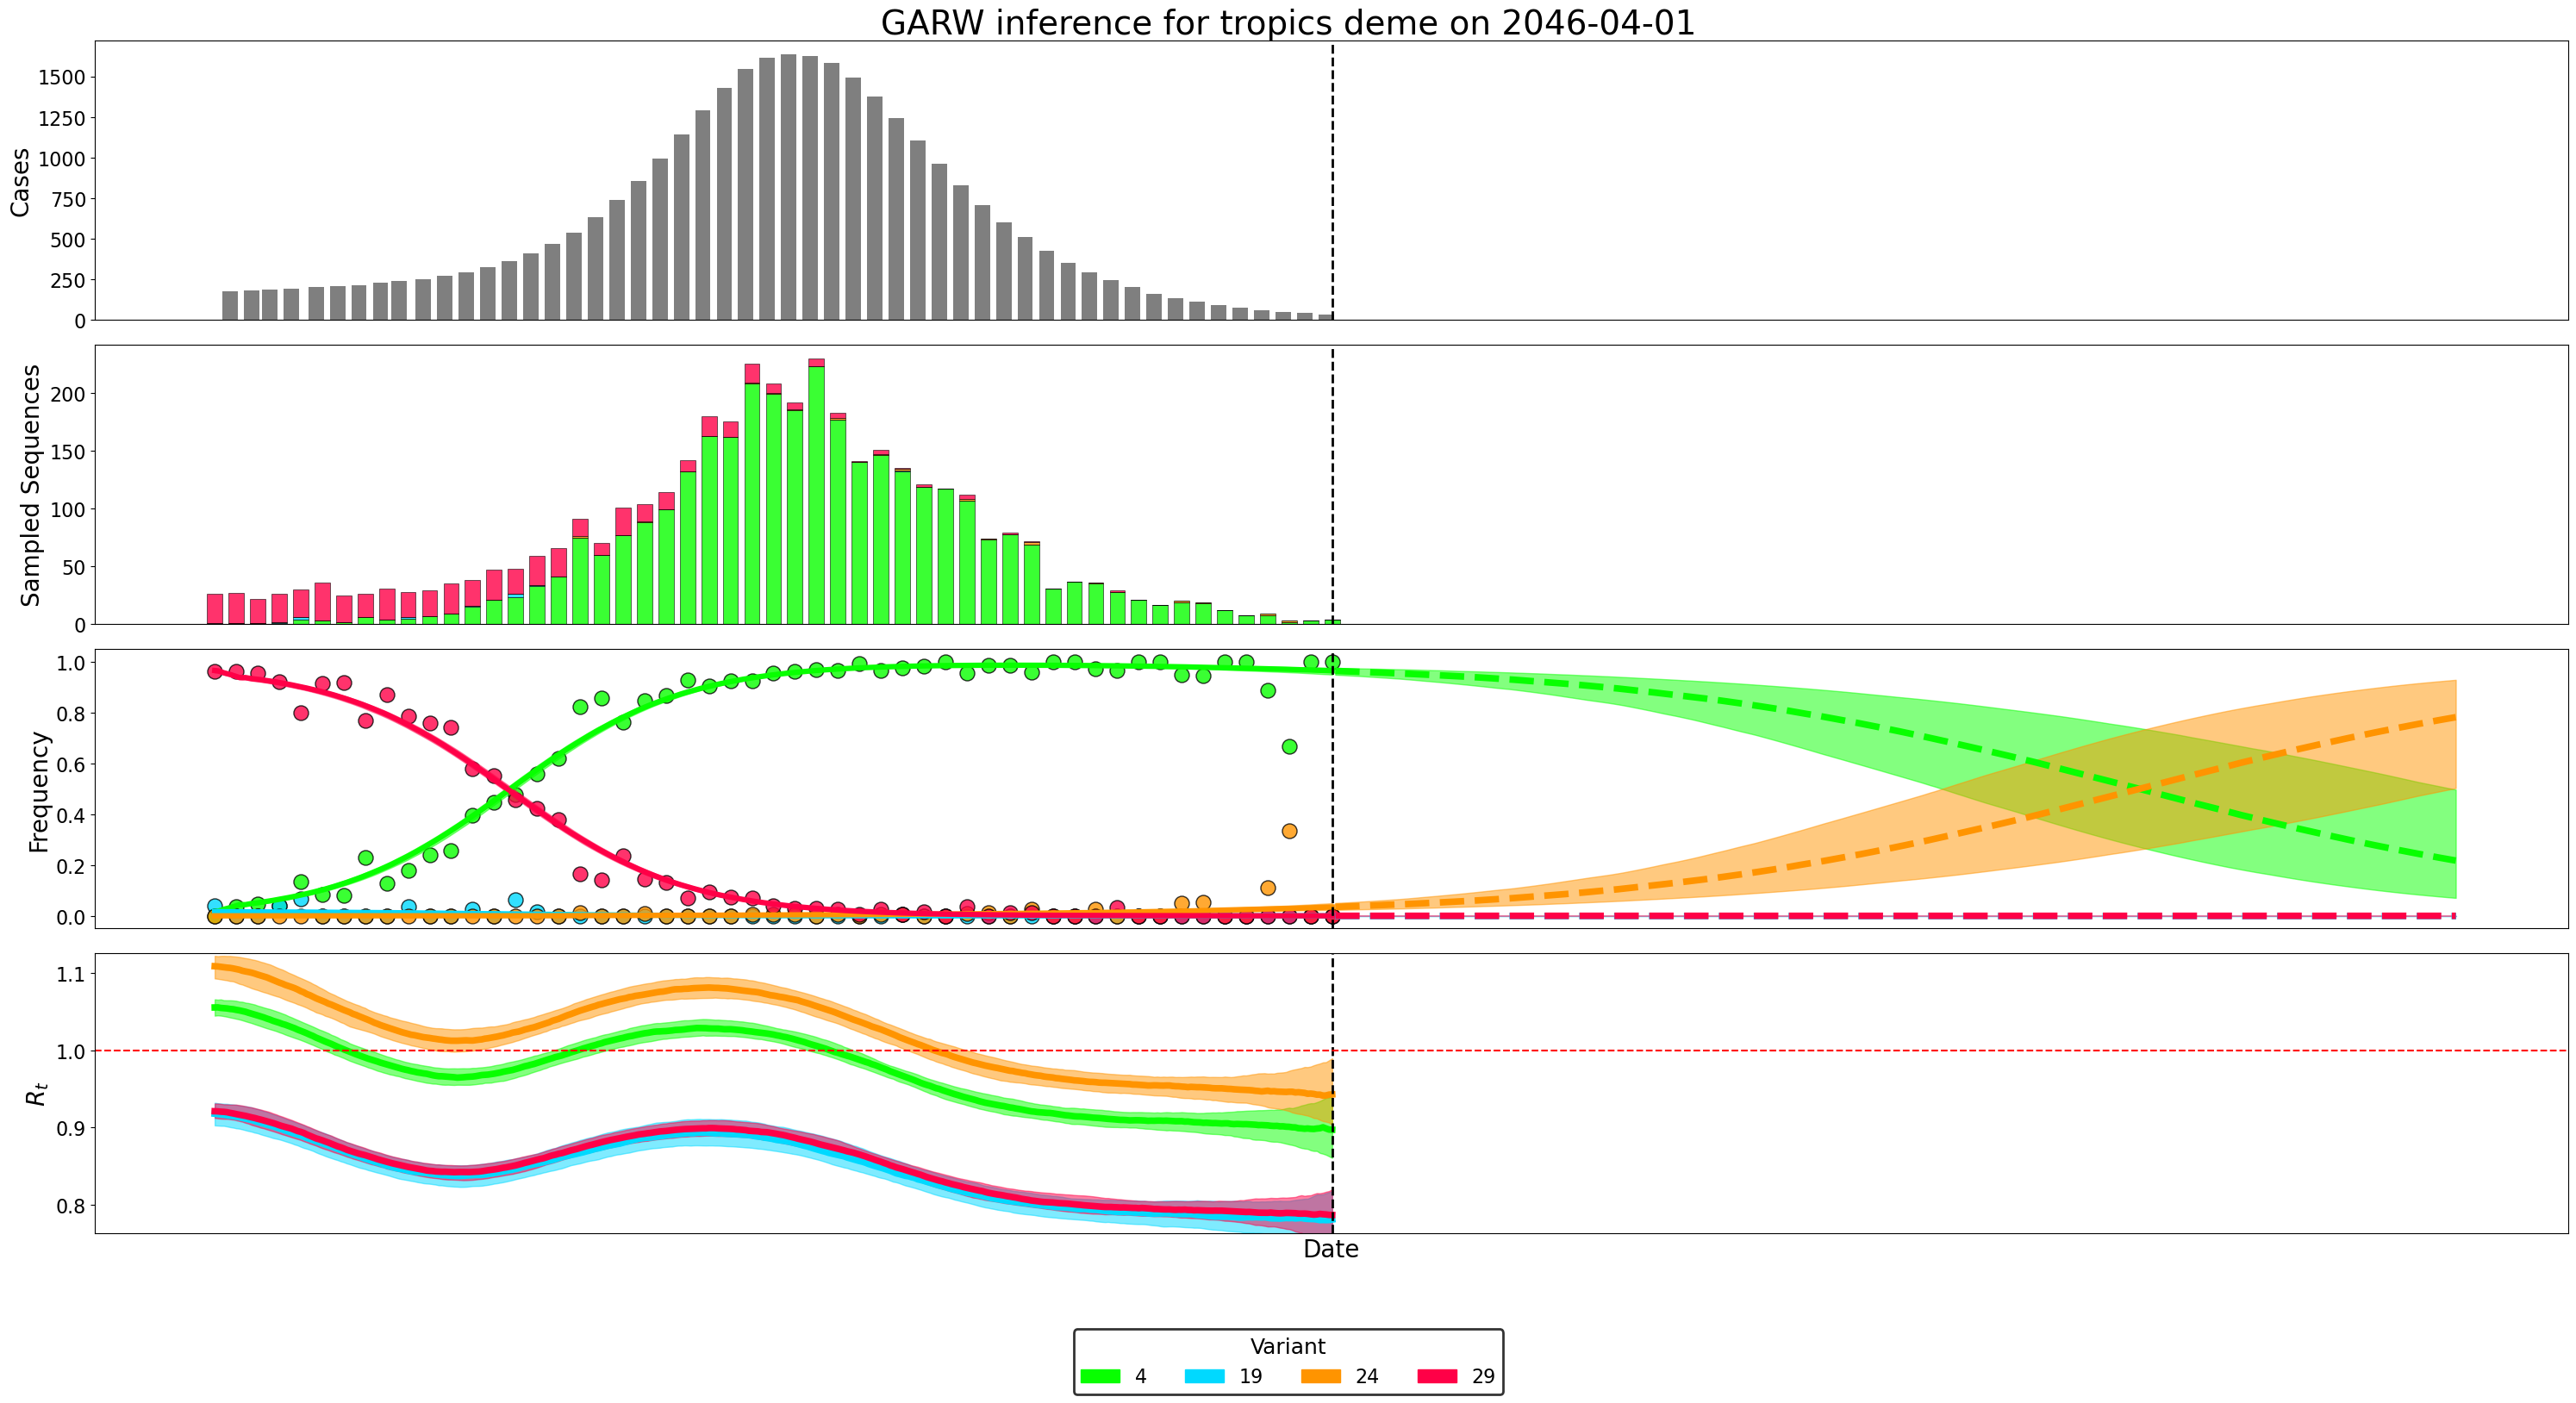

In [4]:
pivot_date="2046-04-01"
location="tropics"
model = "GARW"

growth_rates_df = get_filtered_growth_rates_df(
    build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
plot_analysis_window_with_variant_counts(
    pivot_date=pivot_date, 
    location=location, 
    model=model, 
    build=build, 
    color_map=color_map,
    **presentation_fonts
)

Total cases: 18712.0
Total sequences: 2462.0
Variant counts: [ 227.  102.  177.  828. 1128.]


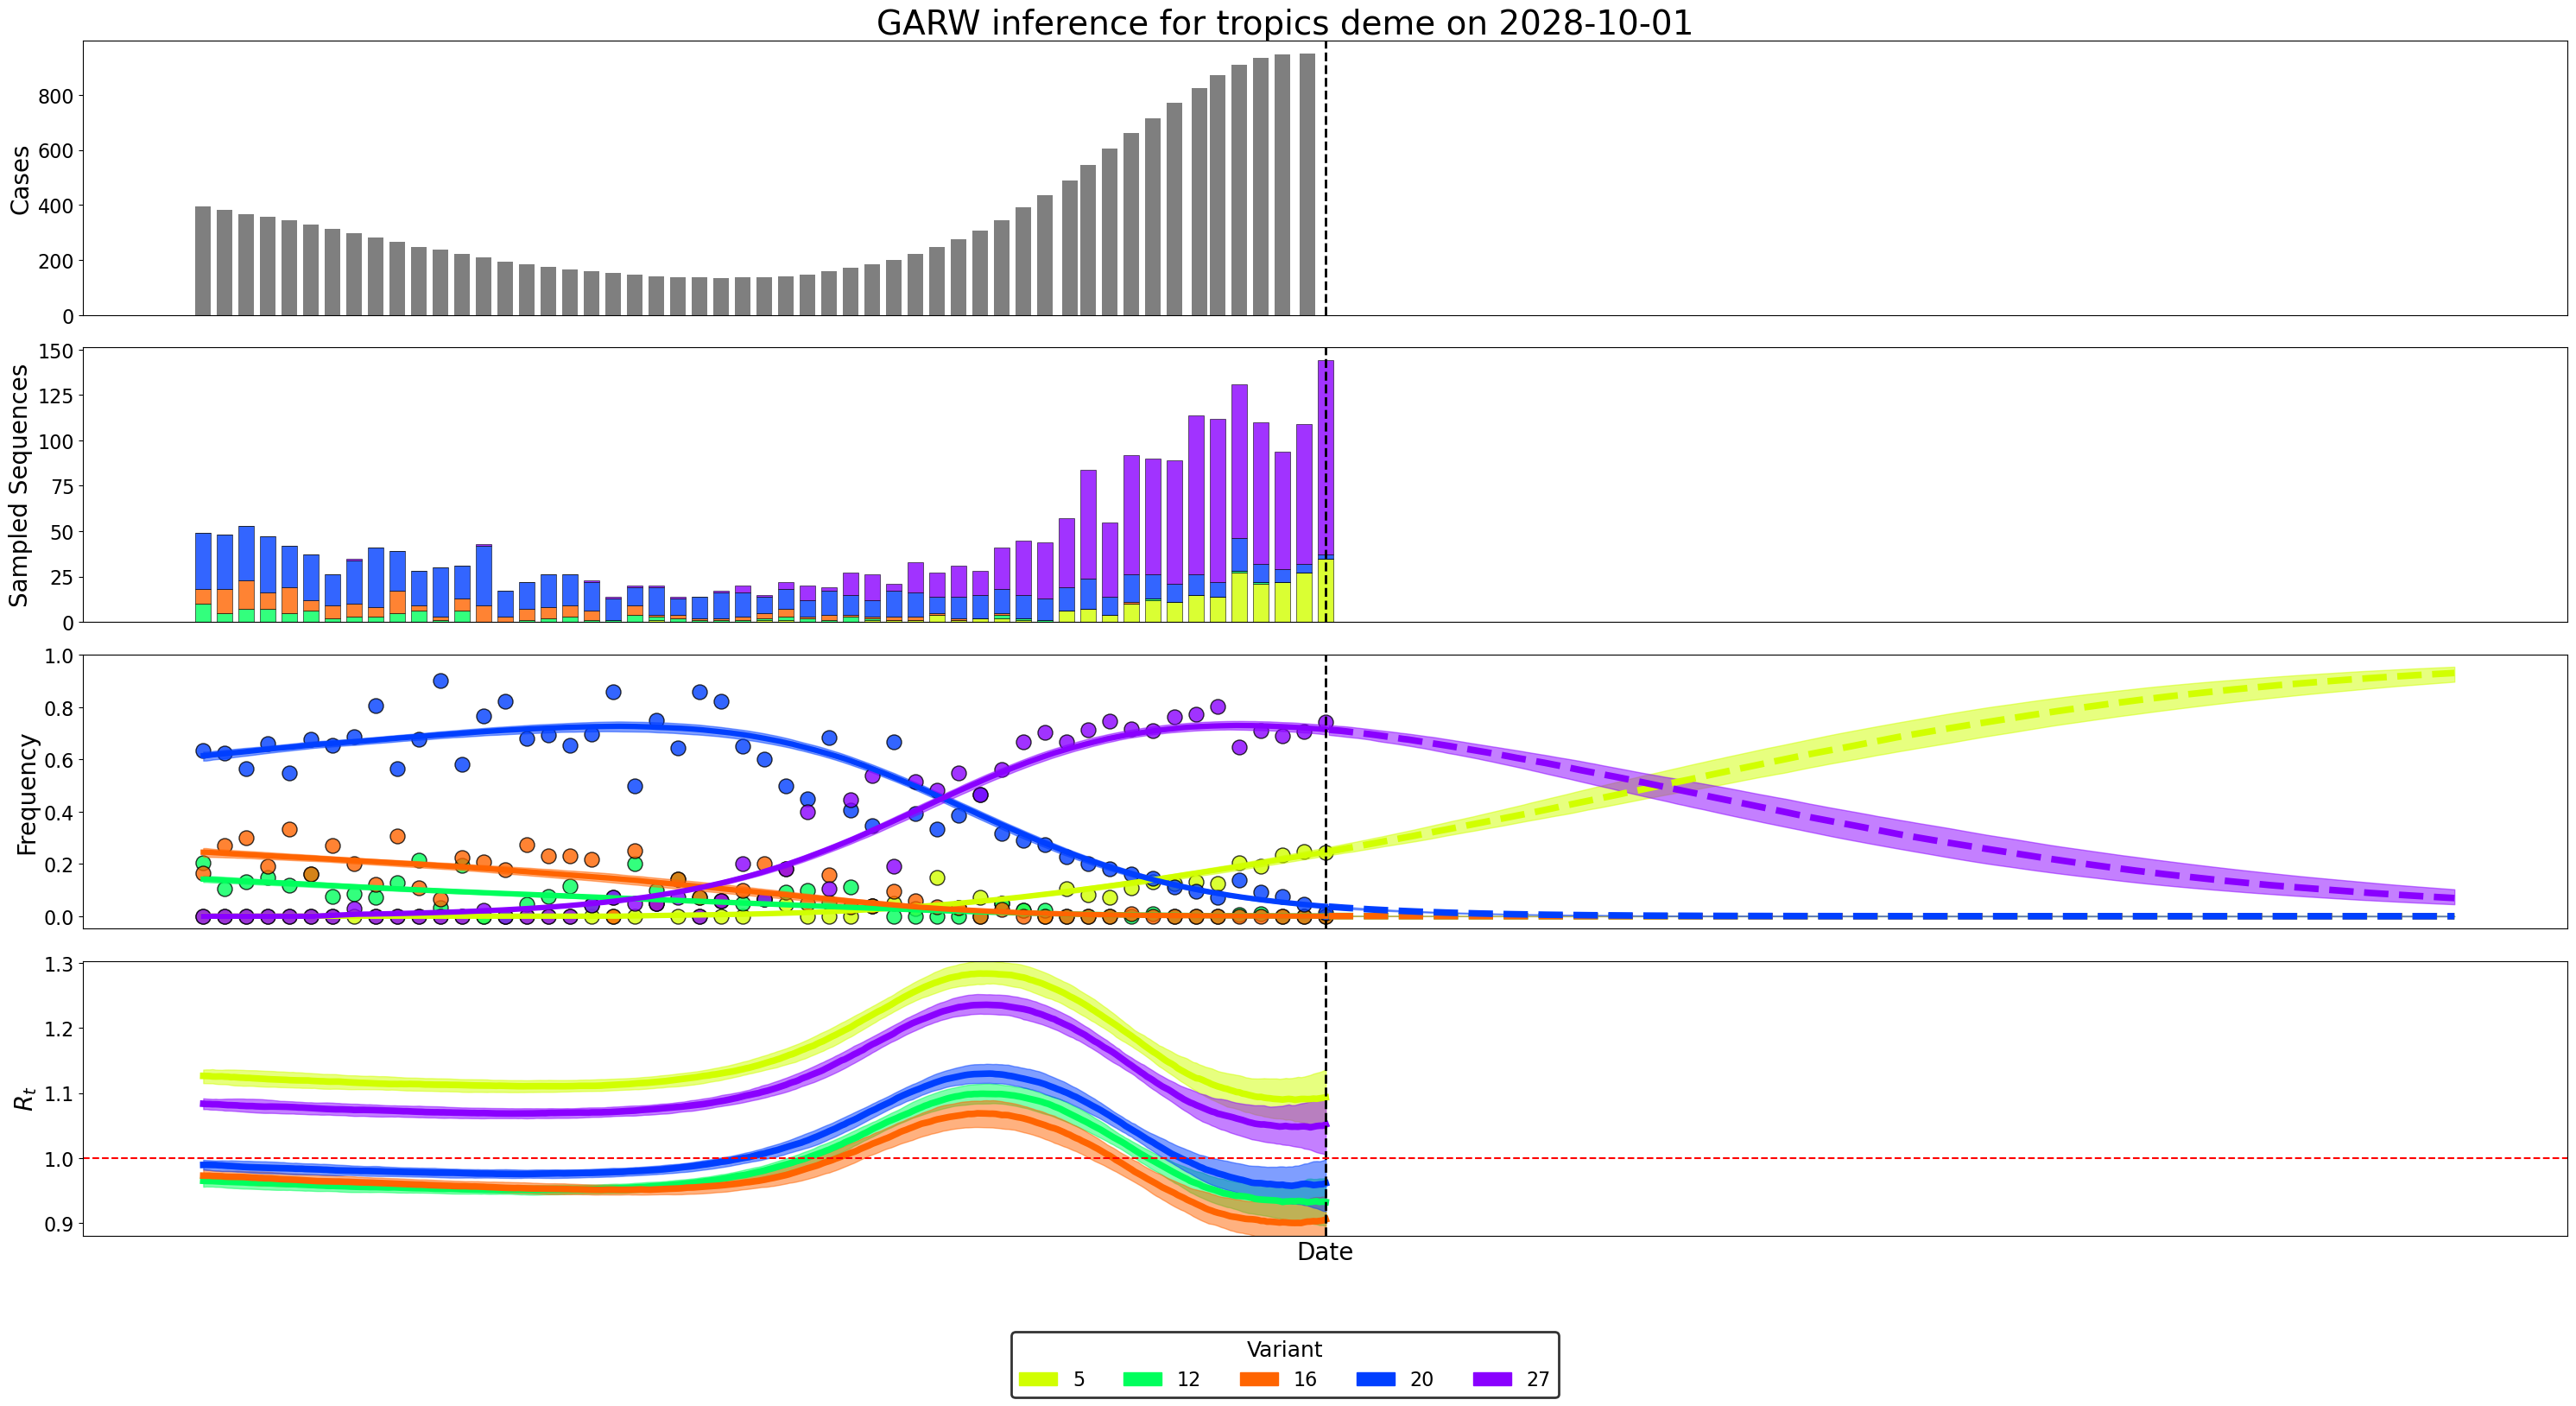

In [7]:
pivot_date="2028-10-01"
location="tropics"
model = "GARW"

growth_rates_df = get_filtered_growth_rates_df(
    build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
plot_analysis_window_with_variant_counts(
    pivot_date=pivot_date, 
    location=location, 
    model=model, 
    build=build, 
    color_map=color_map,
    **presentation_fonts
)

Total cases: 18115.0
Total sequences: 2178.0
Variant counts: [135.  50.   4. 432. 950.  36. 571.]


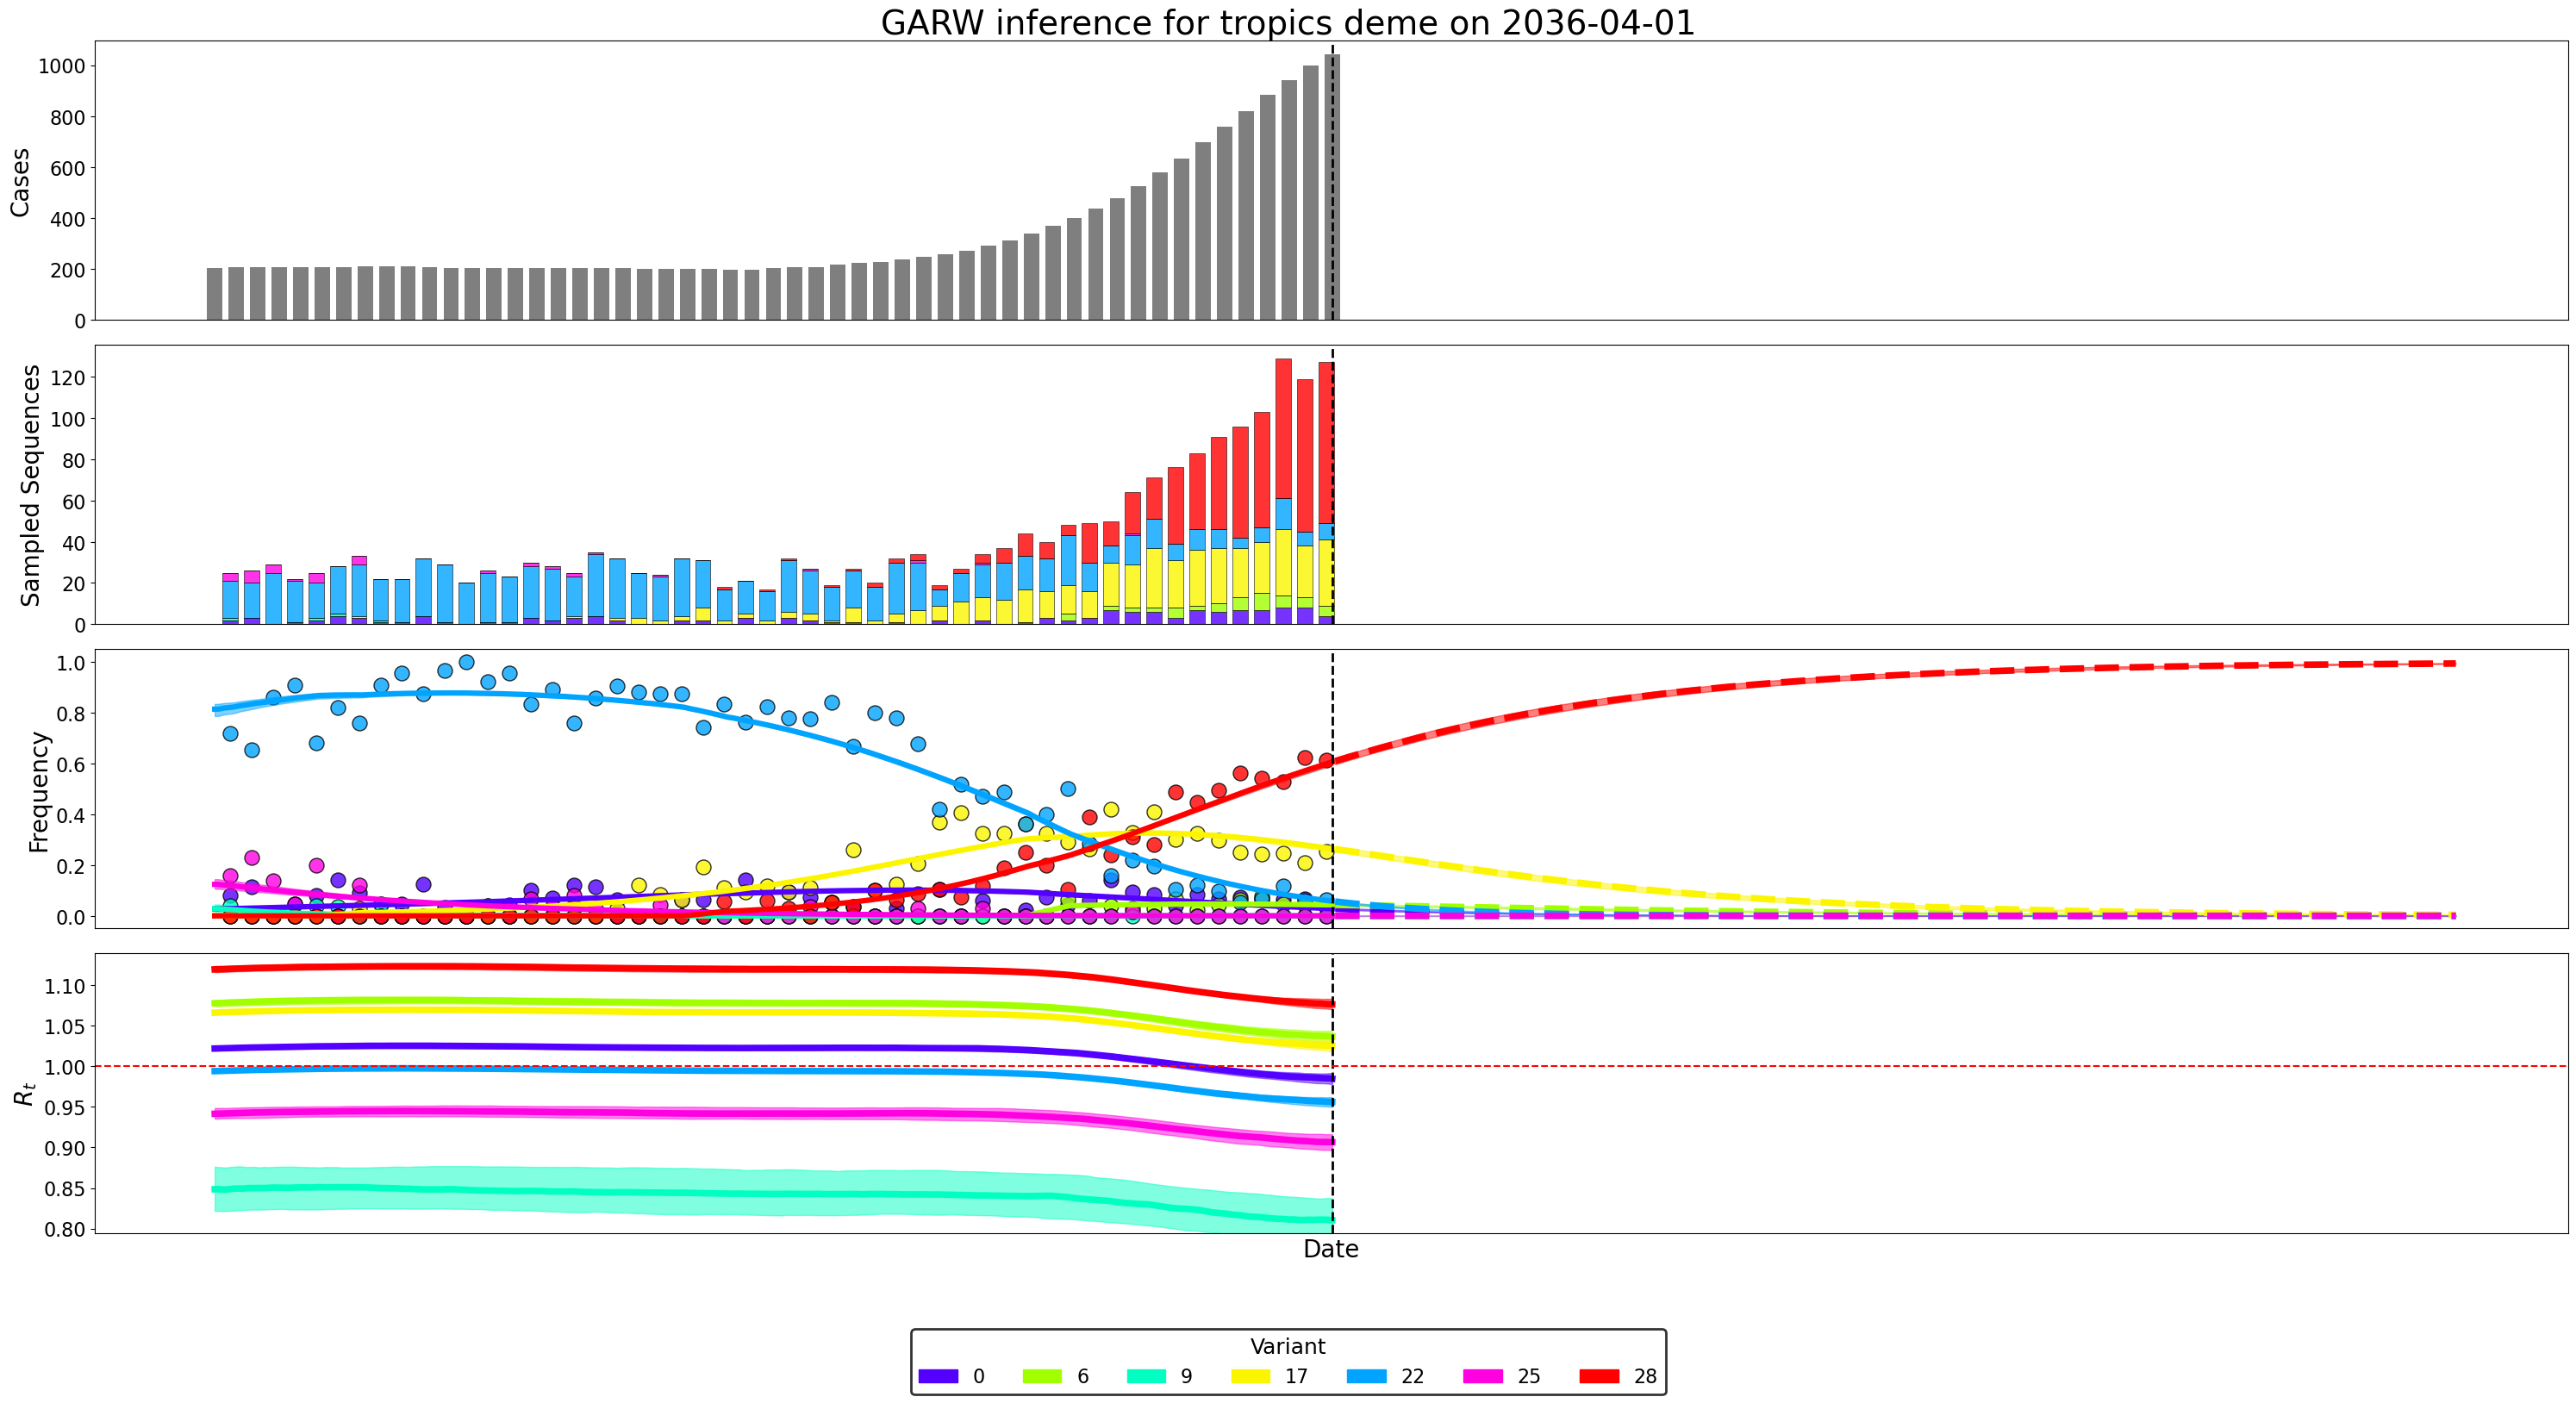

In [8]:
pivot_date="2036-04-01"
location="tropics"
model = "GARW"

growth_rates_df = get_filtered_growth_rates_df(
    build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
plot_analysis_window_with_variant_counts(
    pivot_date=pivot_date, 
    location=location, 
    model=model, 
    build=build, 
    color_map=color_map,
    **presentation_fonts
)

Total cases: 19117.0
Total sequences: 2301.0
Variant counts: [ 45. 455.  11. 909. 881.]


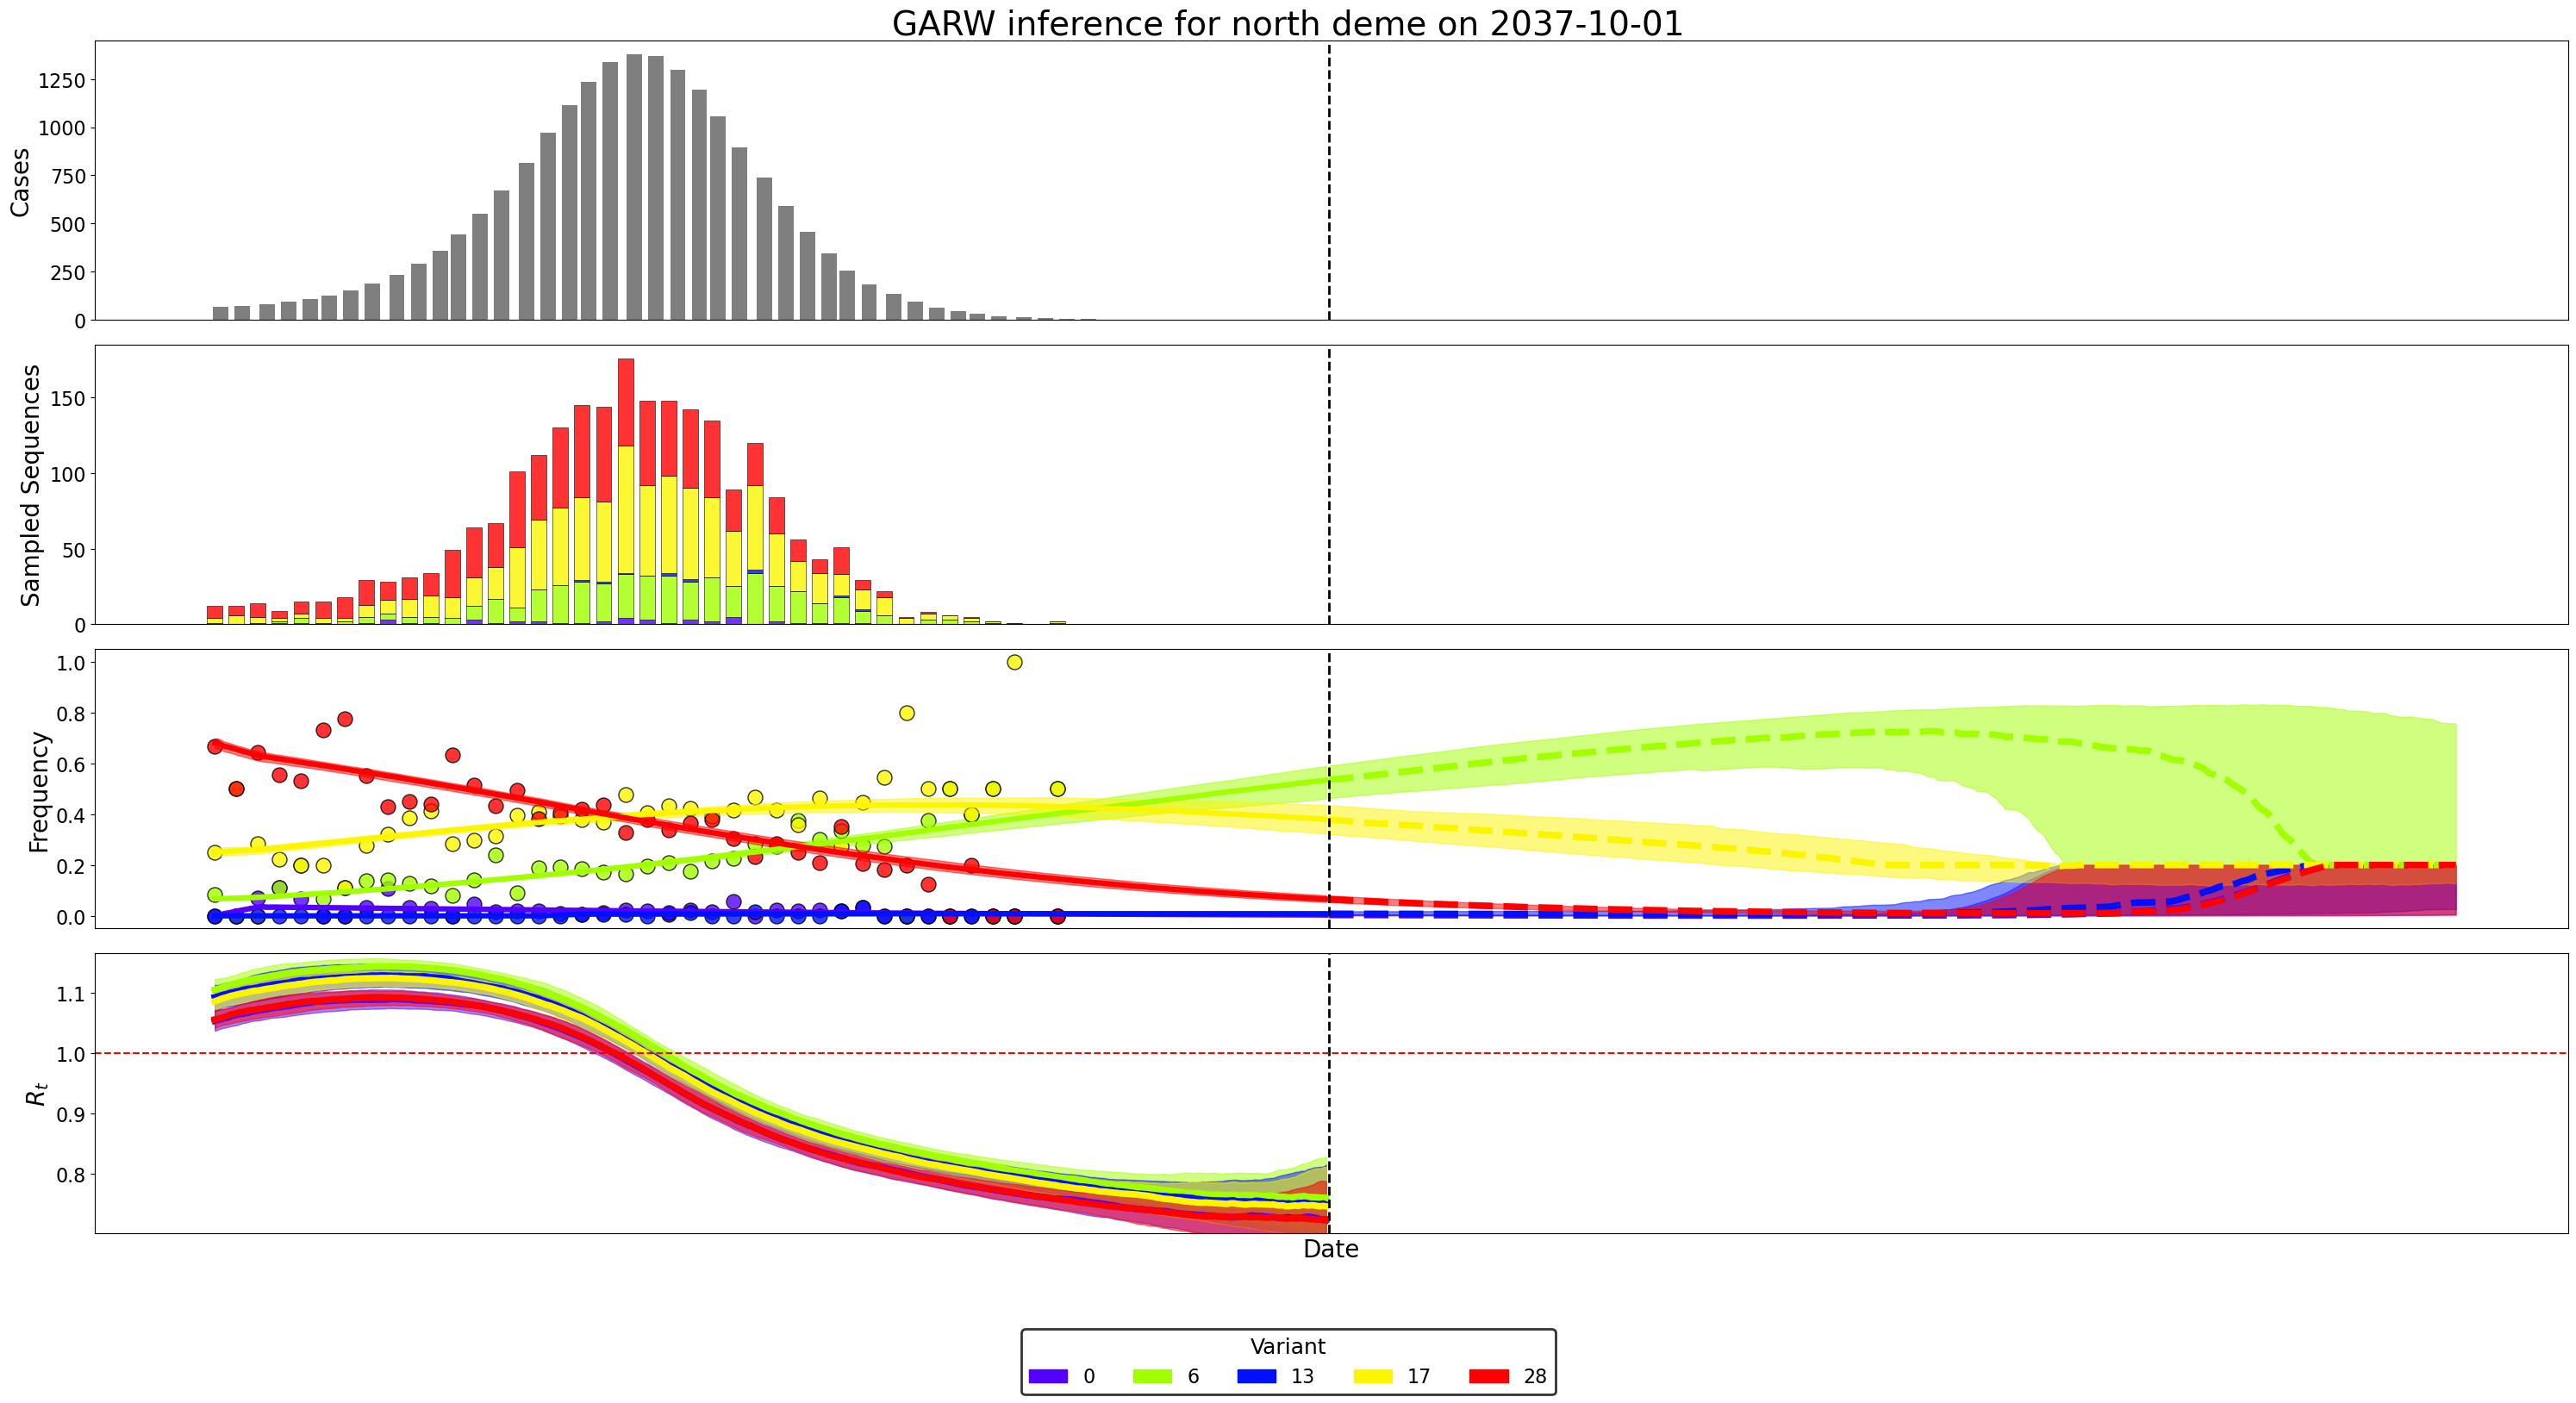

In [15]:
pivot_date="2037-10-01"
location="north"
model = "GARW"

growth_rates_df = get_filtered_growth_rates_df(
    build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
plot_analysis_window_with_variant_counts(
    pivot_date=pivot_date, 
    location=location, 
    model=model, 
    build=build, 
    color_map=color_map,
    **presentation_fonts
)

Total cases: 46178.0
Total sequences: 5400.0
Variant counts: [2.290e+02 8.980e+02 4.252e+03 1.000e+00 2.000e+01]


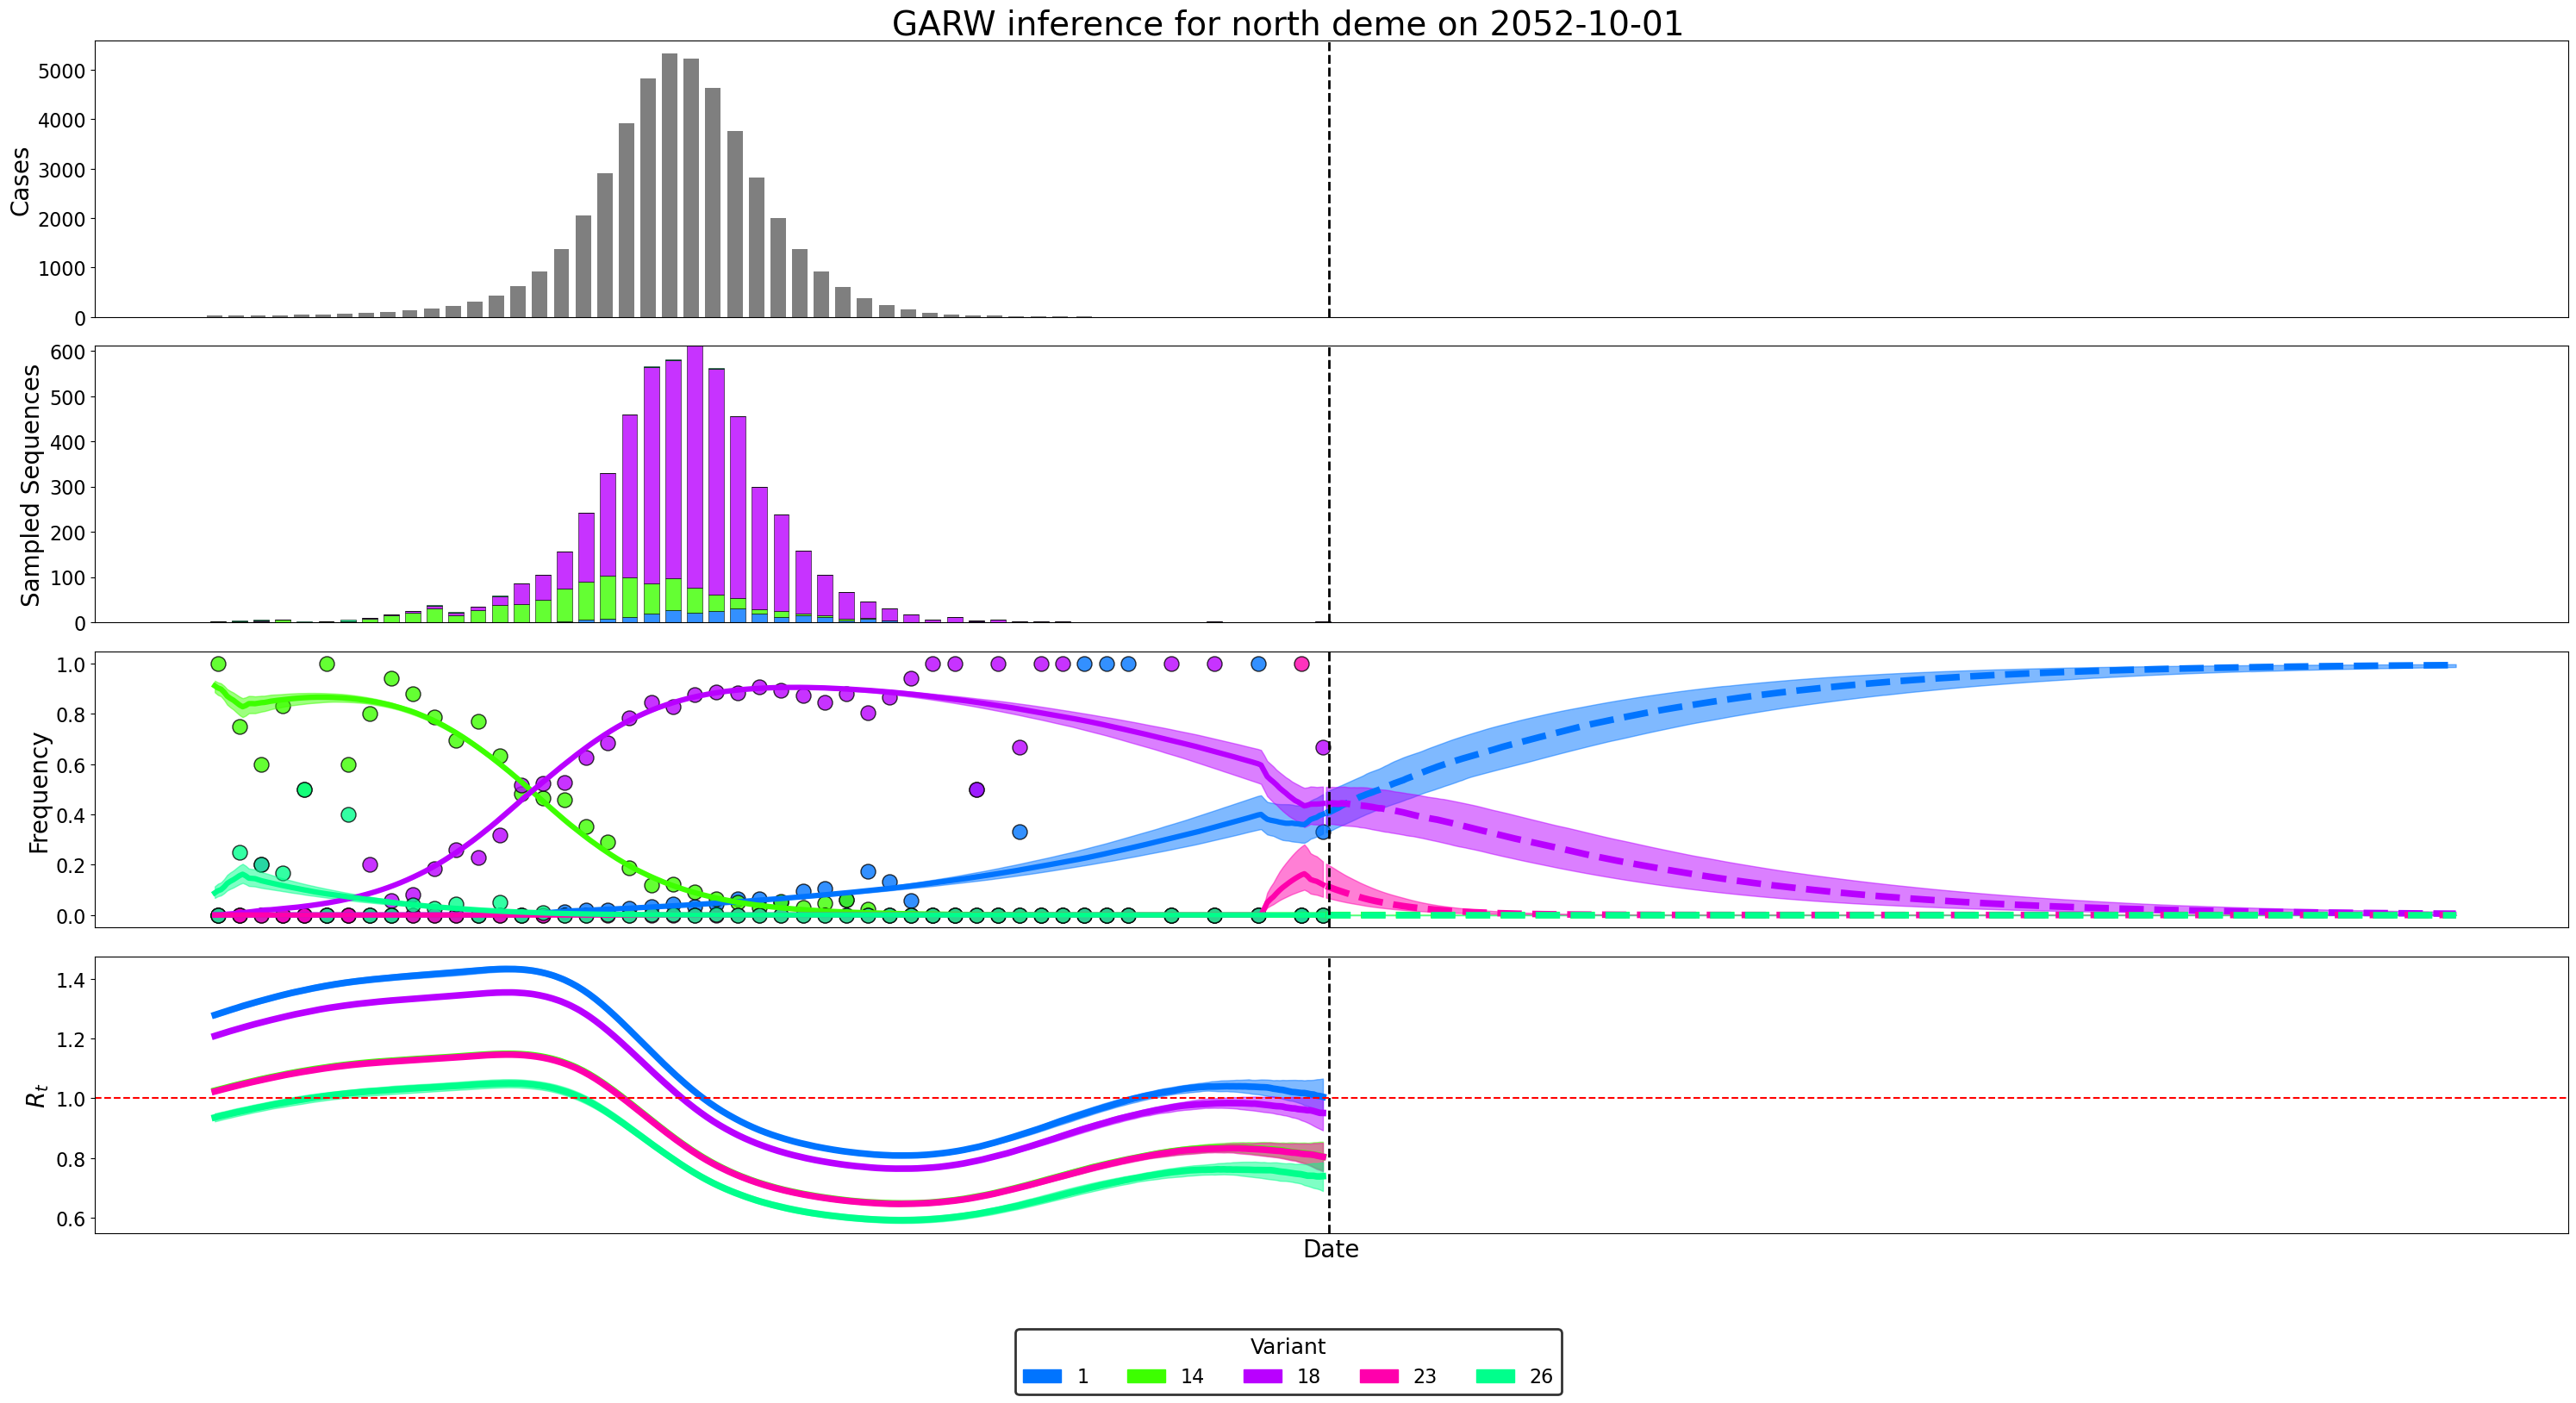

In [17]:
pivot_date="2052-10-01"
location="north"
model = "GARW"

growth_rates_df = get_filtered_growth_rates_df(
    build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
plot_analysis_window_with_variant_counts(
    pivot_date=pivot_date, 
    location=location, 
    model=model, 
    build=build, 
    color_map=color_map,
    **presentation_fonts
)

Total cases: 26073.0
Total sequences: 3047.0
Variant counts: [1.00e+00 1.03e+03 1.78e+03 2.36e+02]


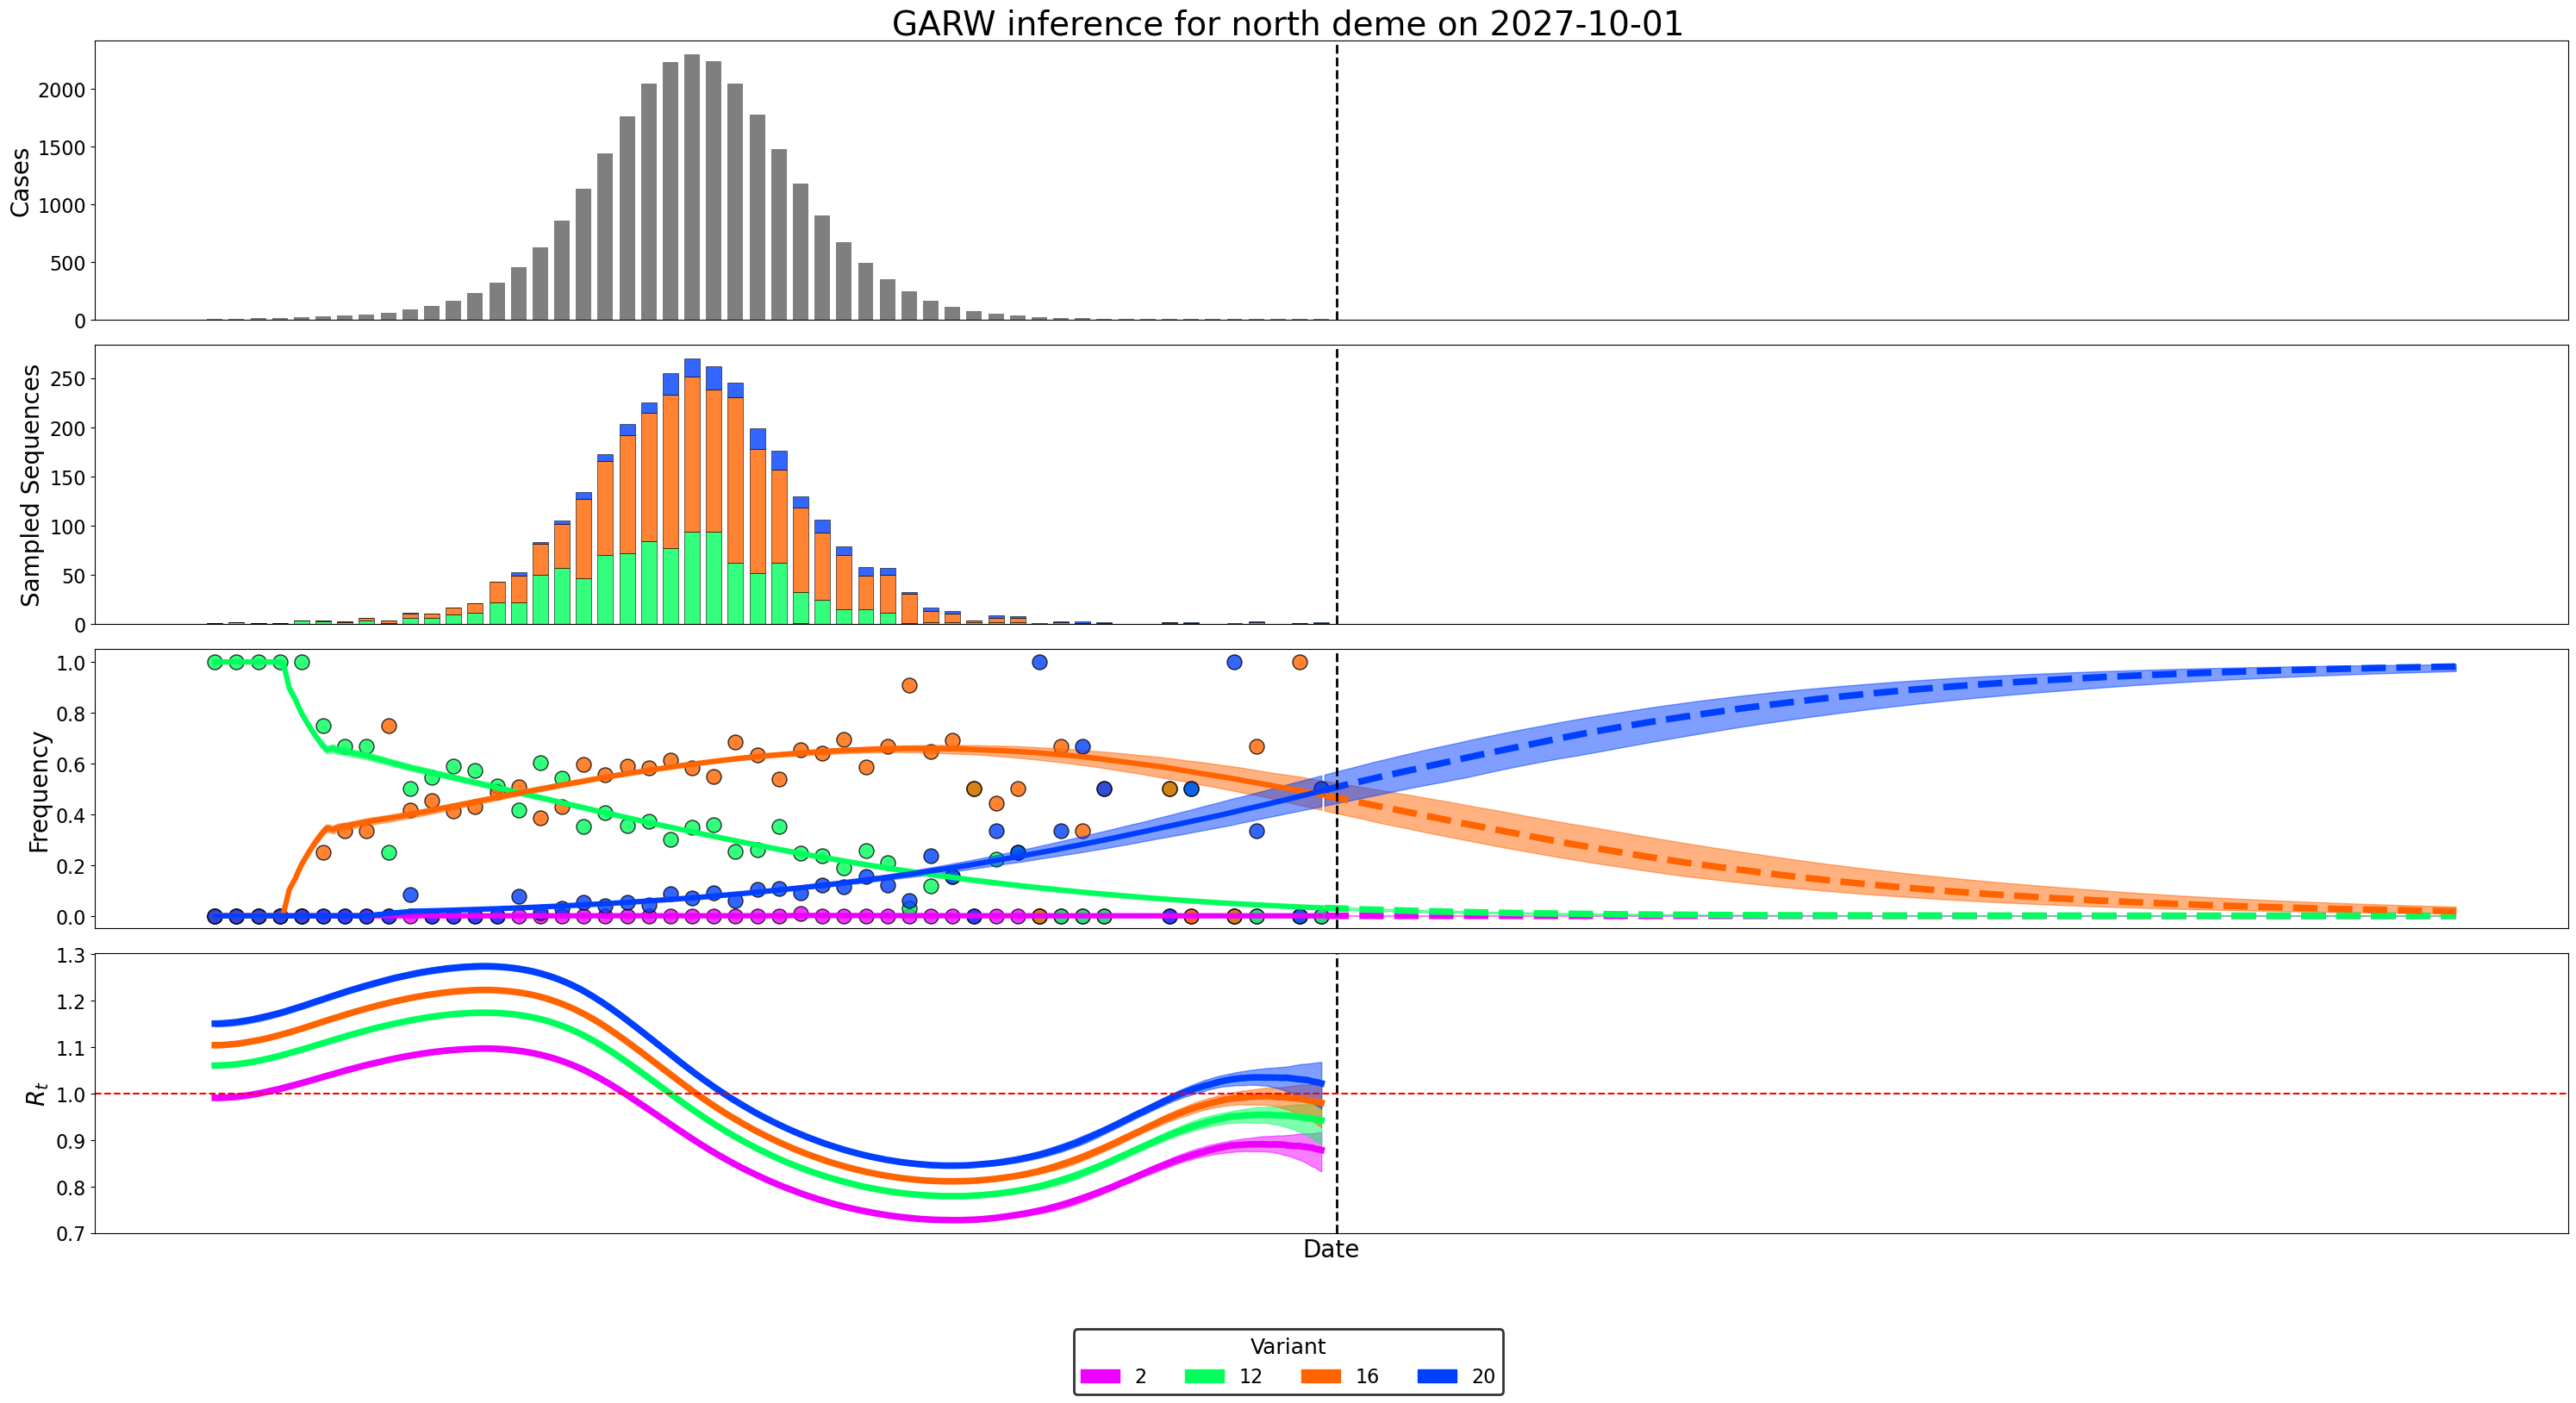

In [18]:
pivot_date="2027-10-01"
location="north"
model = "GARW"

growth_rates_df = get_filtered_growth_rates_df(
    build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
plot_analysis_window_with_variant_counts(
    pivot_date=pivot_date, 
    location=location, 
    model=model, 
    build=build, 
    color_map=color_map,
    **presentation_fonts
)

### Example for figure

Total cases: 30923.0
Total sequences: 3569.0
Variant counts: [1976. 1539.   54.]


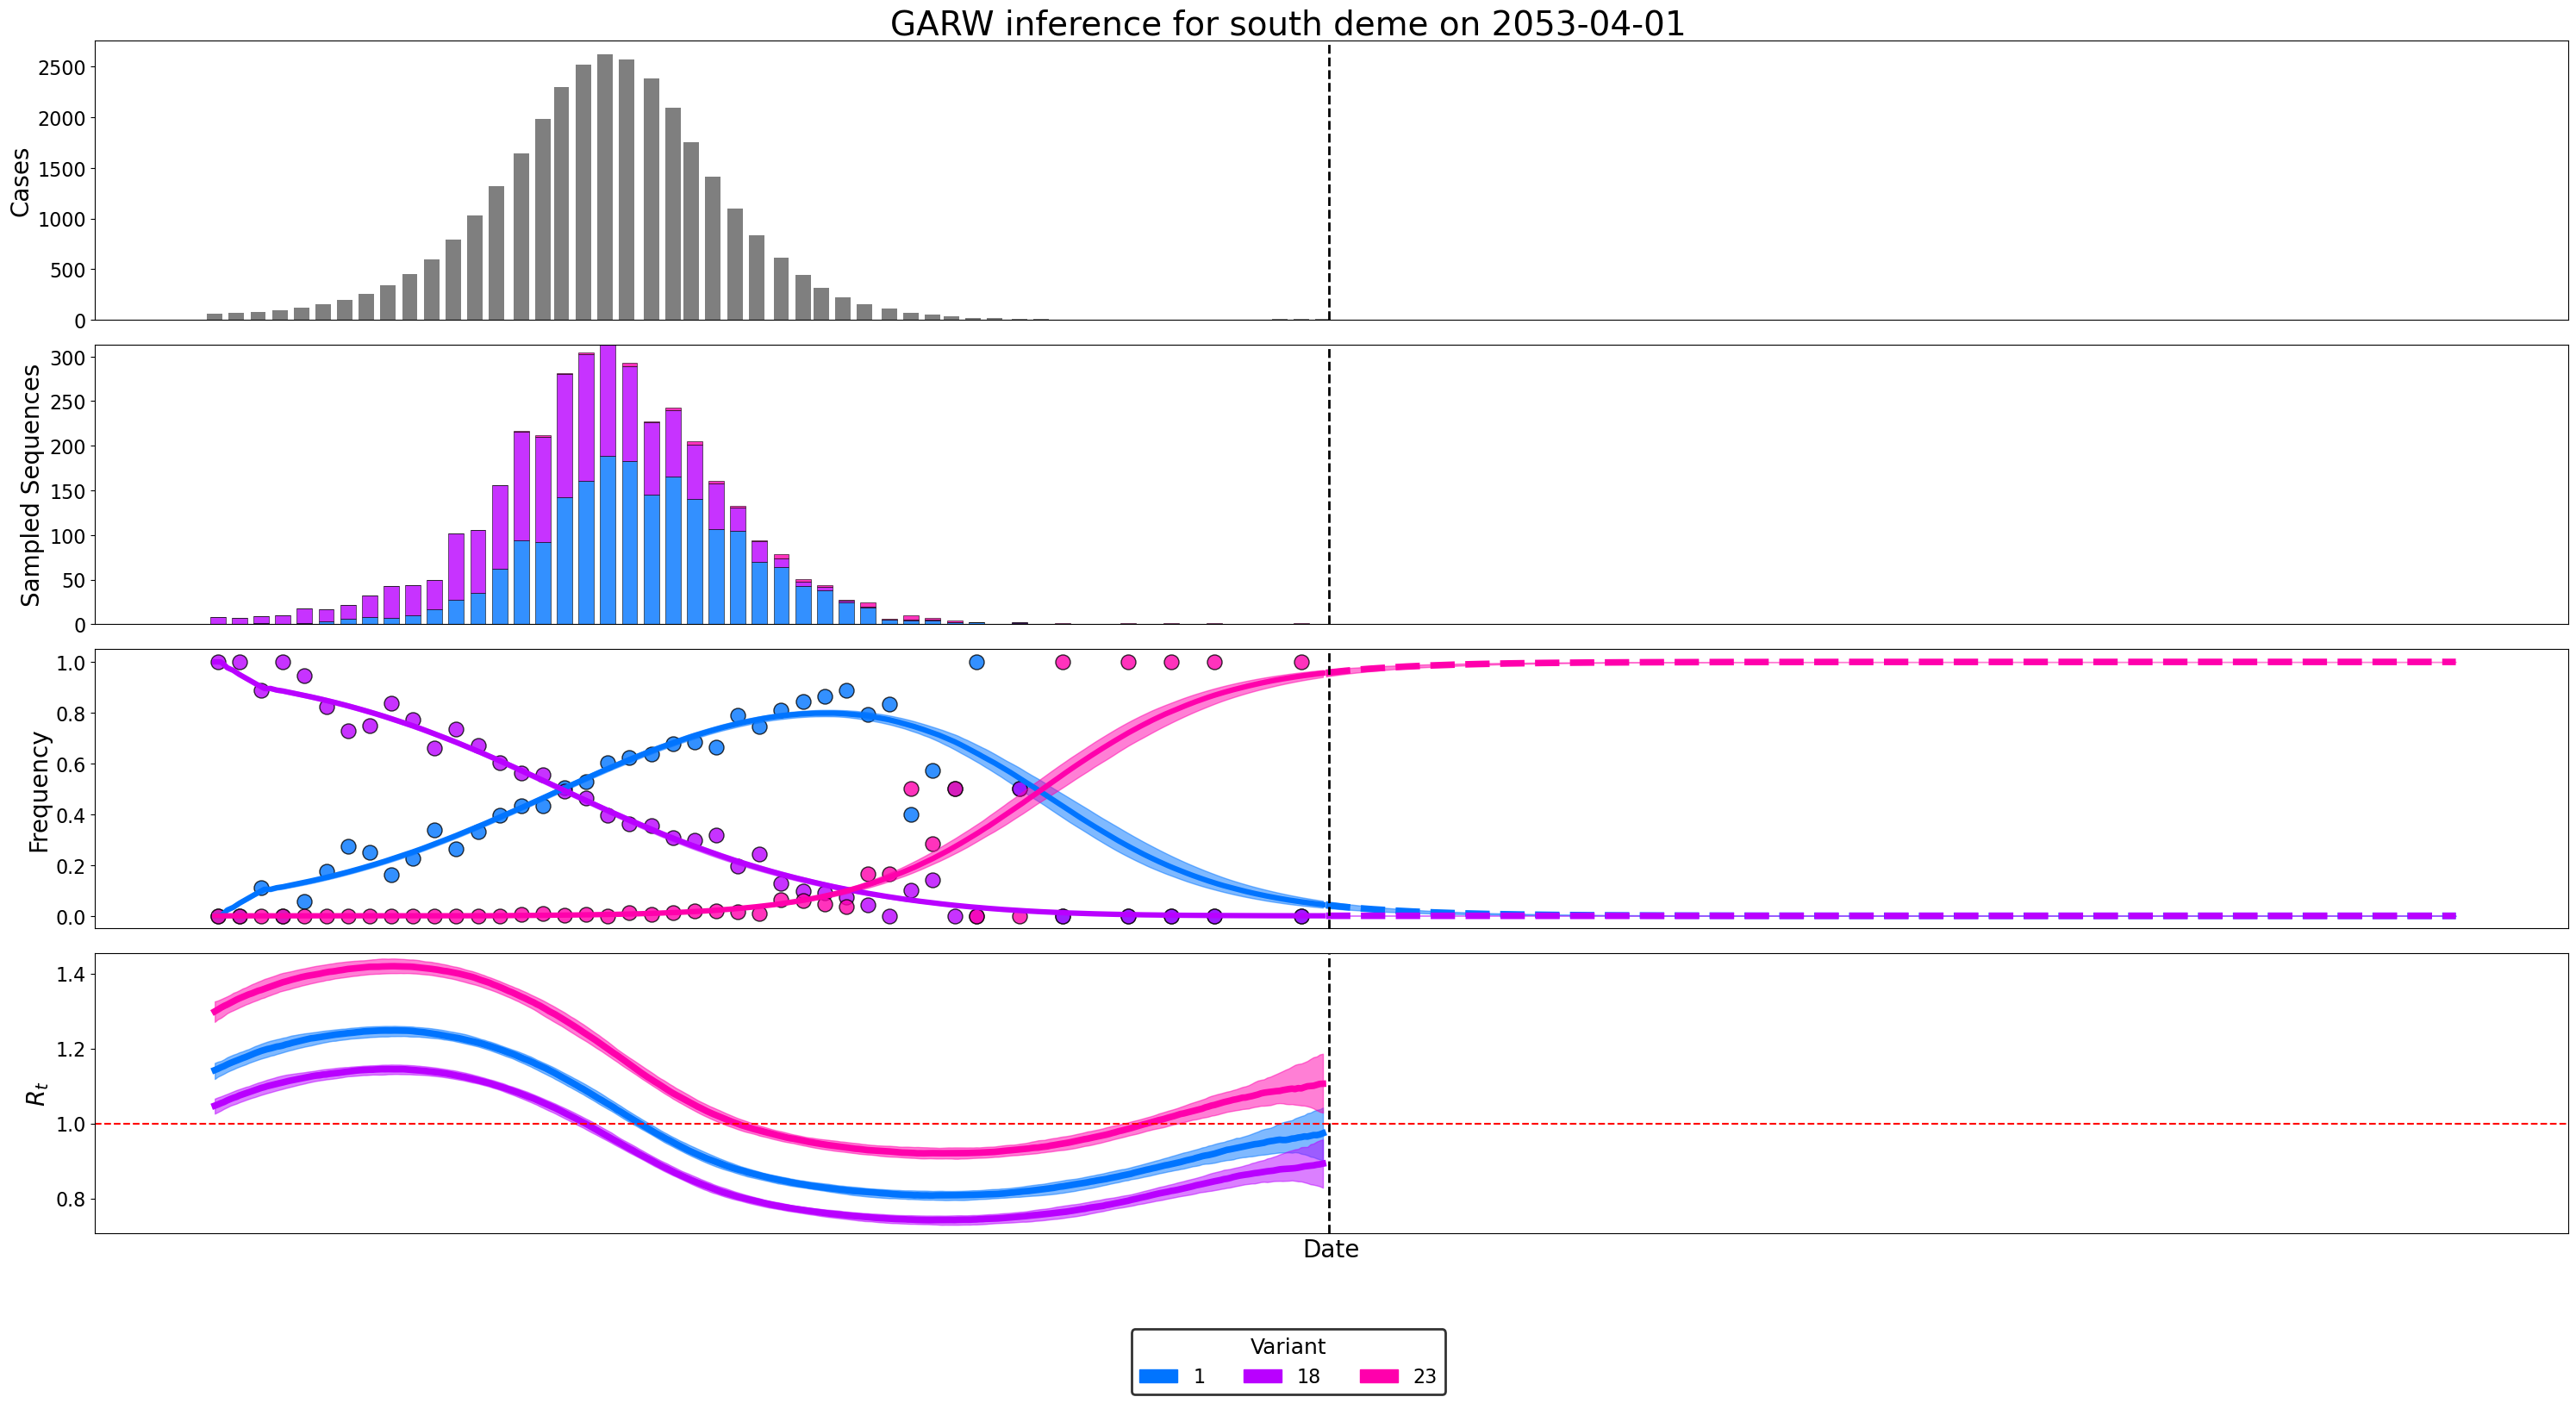

In [19]:
pivot_date="2053-04-01"
location="south"
model = "GARW"

growth_rates_df = get_filtered_growth_rates_df(
    build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)
plot_analysis_window_with_variant_counts(
    pivot_date=pivot_date, 
    location=location, 
    model=model, 
    build=build, 
    color_map=color_map,
    **presentation_fonts
)

## Figure

In [ ]:
def plot_schematic_panel_clean(ax, evo_dict, location, pivot_idx=None):
    """
    Plot a clean schematic panel for publication showing retroactive nowcast vs forecast regions.
    
    Parameters:
    -----------
    ax : matplotlib.axes.Axes
        Axis to plot on
    evo_dict : dict
        Evolution data dictionary from evofr
    location : str
        Location to get date range from
    pivot_idx : list, optional
        List containing pivot index to mark analysis date
    """
    # Get the consistent date range from evofr data but don't restrict other plots
    dates_evofr = pd.to_datetime(evo_dict[location].dates).normalize()
    
    # Don't set xlim - let it inherit from shared x-axis
    ax.set_ylim(0, 1)
    
    # Enable x-axis ticks for date display
    ax.set_yticks([])
    ax.set_ylabel('')
    
    # Get pivot index
    if pivot_idx and len(pivot_idx) > 0:
        pivot_t = pivot_idx[0]
    else:
        # Get from the actual axis limits if available
        xlim = ax.get_xlim()
        pivot_t = (xlim[0] + xlim[1]) / 2  # Default to middle if no pivot provided
    
    # Get the actual x-axis limits (which will be set by other panels)
    xlim = ax.get_xlim()
    if xlim == (0.0, 1.0):  # Default limits, use evofr range
        x_min, x_max = 0, 2*len(dates_evofr) - 1
    else:
        x_min, x_max = xlim
    
    # Add background shading for the two regions
    # Retroactive nowcast region (left of pivot)
    ax.axvspan(x_min, pivot_t, alpha=0.2, color='lightblue', zorder=1)
    
    # Forecast region (right of pivot)  
    ax.axvspan(pivot_t, x_max, alpha=0.2, color='lightcoral', zorder=1)
    
    # Add the pivot line
    ax.axvline(x=pivot_t, color='black', linestyle='--', lw=2.0, zorder=3)
    
    # Add text labels with smaller fonts for publication
    # Retroactive nowcast label (middle of left region)
    nowcast_x = x_min + (pivot_t - x_min) / 2  # Middle of left region
    ax.text(nowcast_x, 0.5, 'Retroactive nowcast', 
            ha='center', va='center', fontsize=10, 
            fontweight='bold', zorder=4)
    
    # Forecast label (middle of right region, positioned further from pivot line)
    forecast_x = pivot_t + (x_max - pivot_t) / 2  # Middle of right region
    ax.text(forecast_x, 0.5, 'Forecast', 
            ha='center', va='center', fontsize=10,
            fontweight='bold', zorder=4)
    
    # Add analysis date label at the pivot line
    ax.text(pivot_t, 0.85, 'Analysis date', 
            ha='center', va='center', fontsize=9,
            fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
            zorder=5)
    
    # Remove all spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

In [ ]:
def plot_frequencies_clean(
    ax: plt.Axes, 
    ef_data: Dict[str, Any], 
    freqs: pd.DataFrame, 
    deme: str, 
    model: str, 
    color_map: Dict[str, str], 
    p: int = 50, 
    pivot_idx: Optional[List[int]] = None,
    build: str = None,
    pivot_date: str = None
) -> None:
    """ Plot observed and predicted frequencies in a clean style for publication."""
    # Get variant names
    v_names = sorted(ef_data[deme].var_names)
    n_variant = len(v_names)
    
    # Calculate observed frequencies
    obs_freq = np.divide(ef_data[deme].seq_counts, ef_data[deme].seq_counts.sum(axis=1)[:, None])
    t = np.arange(0, obs_freq.shape[0])

    # Grab predicted frequencies of interest
    deme_freq = freqs.query(f'location == "{deme}" and model == "{model}"')
    for variant in range(n_variant):
        v_name = v_names[variant]
        variant_df = deme_freq.query(f'variant == {v_name}')
        # Plot observed frequencies
        ax.scatter(t, obs_freq[:, variant], color=color_map[v_name], alpha=0.8, s=30, edgecolors='black', linewidth=0.5)
        # Plot nowcasts (no label to avoid legend)
        ax.plot(variant_df['t'], variant_df['median_freq_nowcast'], lw=2, color=color_map[v_name])
        ax.fill_between(variant_df['t'], variant_df[f'freq_lower_{p}'], variant_df[f'freq_upper_{p}'], color=color_map[v_names[variant]], alpha=0.3)
        # Plot forecasts (no label to avoid legend)
        ax.plot(variant_df['t'], variant_df['median_freq_forecast'], lw=2, color=color_map[v_name], linestyle='--')
        ax.fill_between(variant_df['t'], variant_df[f'freq_forecast_lower_{p}'], variant_df[f'freq_forecast_upper_{p}'], color=color_map[v_names[variant]], alpha=0.3)
    
    # Add observed frequencies in forecast region if data available
    if build and pivot_date and pivot_idx:
        try:
            # Calculate next pivot date
            pivot_dt = pd.to_datetime(pivot_date)
            if pivot_dt.month == 4:
                next_pivot = f"{pivot_dt.year}-10-01"
            else:  # month == 10
                next_pivot = f"{pivot_dt.year + 1}-04-01"
            
            # Load next pivot data to get observed frequencies during forecast period
            dummy_fitness_df = pd.DataFrame(columns=['date', 'location', 'variant', 'fitness', 'seasonal_fitness', 't'])
            next_evo_dict, _, _, _ = get_analysis_window(next_pivot, build, dummy_fitness_df)
            
            if deme in next_evo_dict:
                # Get variant names from both datasets
                current_variants = set(ef_data[deme].var_names)
                next_variants = set(next_evo_dict[deme].var_names)
                
                # Calculate observed frequencies from next dataset
                next_obs_freq = np.divide(
                    next_evo_dict[deme].seq_counts, 
                    next_evo_dict[deme].seq_counts.sum(axis=1)[:, None]
                )
                next_t = np.arange(0, next_obs_freq.shape[0])
                
                # Map next_t values to current coordinate system
                # The forecast period in current coordinates starts at pivot_t
                pivot_t = pivot_idx[0] if pivot_idx else 0
                forecast_t_values = next_t + pivot_t
                
                # Only plot points that fall in the forecast region
                ax_xlim = ax.get_xlim()
                x_max = ax_xlim[1] if ax_xlim != (0.0, 1.0) else len(t) + len(next_t)
                forecast_mask = (forecast_t_values > pivot_t) & (forecast_t_values <= x_max)
                
                # Track novel variants for legend (to avoid duplicate legend entries)
                novel_variants_plotted = set()
                
                # Plot observed forecast frequencies for ALL variants in the future dataset
                for i, v_name in enumerate(next_evo_dict[deme].var_names):
                    # Filter to forecast region
                    valid_t = forecast_t_values[forecast_mask]
                    valid_freq = next_obs_freq[forecast_mask, i]
                    
                    if len(valid_t) > 0:
                        # Determine if this is a known variant (was in training) or novel variant
                        if v_name in current_variants:
                            # Known variant: use circle markers with variant color (matching nowcast style)
                            variant_color = color_map.get(v_name, 'gray')
                            ax.scatter(valid_t, valid_freq, 
                                     color=variant_color, alpha=0.8, s=30, 
                                     edgecolors='black', linewidth=0.5, zorder=10)
                        else:
                            # Novel variant: use X markers with variant color 
                            # No label to avoid cluttering with individual legends
                            if v_name in color_map:
                                variant_color = color_map[v_name]
                            else:
                                variant_color = 'black'
                            
                            ax.scatter(valid_t, valid_freq, 
                                     color=variant_color, alpha=0.8, s=30, 
                                     marker='x', linewidth=2, zorder=10)
                                     
        except Exception as e:
            # If loading next pivot fails, continue without observed forecast frequencies
            print(f"Could not load observed frequencies for forecast region: {e}")
    
    if pivot_idx:
        for idx in pivot_idx:
            ax.axvline(x=idx, color='black', linestyle='--', lw=1.5, alpha=0.5)
    ax.set_xticks([])
    ax.set_ylabel("Frequency", fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(0, 1.05)


def plot_variant_incidence_clean(ax, growth_rates_df, location, color_map, evo_dict, pivot_idx=None):
    """
    Plot variant incidence in a clean style for publication.
    """
    # Filter for the specific location
    location_data = growth_rates_df[growth_rates_df['country'] == location].copy()
    
    if location_data.empty:
        ax.text(0.5, 0.5, f'No incidence data for {location}', 
                transform=ax.transAxes, ha='center', va='center', fontsize=10)
        ax.set_ylabel('Variant incidence', fontsize=10)
        return
    
    # Get the consistent date mapping from evofr data
    dates_evofr = pd.to_datetime(evo_dict[location].dates).normalize()
    date_to_t = {date: i for i, date in enumerate(dates_evofr)}
    
    # Get unique variants
    variants = sorted(location_data['variant'].unique())
    
    # Plot incidence for each variant
    for variant in variants:
        variant_data = location_data[location_data['variant'] == variant].copy()
        
        if variant_data.empty or 'variant_incidence_smoothed' not in variant_data.columns:
            continue
        
        # Convert week_start to normalized datetime
        variant_data['week_start_norm'] = pd.to_datetime(variant_data['week_start']).dt.normalize()
        
        # Map week_start dates to t values using the evofr date mapping
        t_values = []
        incidence_values = []
        for idx, row in variant_data.iterrows():
            week_date = row['week_start_norm']
            # Find the closest date in our evofr date mapping
            if week_date in date_to_t:
                t_values.append(date_to_t[week_date])
                incidence_values.append(row['variant_incidence_smoothed'])
            else:
                # Find closest date if exact match not found
                date_diffs = [(abs((date - week_date).days), date) for date in dates_evofr]
                if date_diffs:
                    min_diff, closest_date = min(date_diffs)
                    if min_diff <= 7:  # Only include if within a week
                        t_values.append(date_to_t[closest_date])
                        incidence_values.append(row['variant_incidence_smoothed'])
        
        if not t_values:
            continue
            
        # Get color for this variant
        variant_color = color_map.get(variant, 'gray')
        
        # Plot as line (no label to avoid legend)
        ax.plot(t_values, incidence_values, 
               color=variant_color, linewidth=2.5)
    
    # Add vertical lines for pivot indices
    if pivot_idx:
        for idx in pivot_idx:
            ax.axvline(x=idx, color='black', linestyle='--', lw=1.5, alpha=0.5)
    
    # Set labels and formatting
    ax.set_ylabel('Variant incidence', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

In [ ]:
def plot_r_data_vs_r_model_clean(ax, growth_rates_df, location, color_map, evo_dict, pivot_idx=None):
    """
    Plot r_data (observed) vs r_model (inferred) growth rates in a clean style for publication.
    """
    # Filter for the specific location
    location_data = growth_rates_df[growth_rates_df['country'] == location].copy()
    
    if location_data.empty:
        ax.text(0.5, 0.5, f'No growth rate data for {location}', 
                transform=ax.transAxes, ha='center', va='center', fontsize=10)
        ax.set_ylabel('Growth rate (r)', fontsize=10)
        return
    
    # Get the consistent date mapping from evofr data
    dates_evofr = pd.to_datetime(evo_dict[location].dates).normalize()
    date_to_t = {date: i for i, date in enumerate(dates_evofr)}
    
    # Get unique variants
    variants = sorted(location_data['variant'].unique())
    
    # Plot growth rates for each variant
    for variant in variants:
        variant_data = location_data[location_data['variant'] == variant].copy()
        
        if variant_data.empty:
            continue
            
        # Get color for this variant
        variant_color = color_map.get(variant, 'gray')
        
        # Convert week_start to normalized datetime and add to variant data
        variant_data['week_start_norm'] = pd.to_datetime(variant_data['week_start']).dt.normalize()
        
        # Apply the same filtering logic as plot_growth_rate_dynamics
        # First, basic NaN filtering for growth_rate_r_data
        valid_r_data = variant_data[~variant_data['growth_rate_r_data'].isna()].copy()
        
        # Apply advanced segment filtering if MIN_SEGMENT_LENGTH is specified
        if MIN_SEGMENT_LENGTH is not None:
            # Create a temporary DataFrame for this variant to apply filtering
            temp_df = variant_data.copy()
            temp_df['country'] = location  # Ensure location column exists for filtering
            temp_df['variant'] = variant   # Ensure variant column exists for filtering  
            temp_df['date'] = temp_df['week_start_norm']  # Use week_start as date for filtering
            
            filtered_variant_data = filter_growth_rates(
                temp_df, 
                r_data_col='growth_rate_r_data', 
                connect_gaps=CONNECT_GAPS, 
                min_segment_length=MIN_SEGMENT_LENGTH
            )
            valid_r_data = filtered_variant_data[~filtered_variant_data['growth_rate_r_data'].isna()].copy()
        
        # For median_r, use the same filtered data for consistency (same logic as plot_growth_rate_dynamics)
        if len(valid_r_data) > 0 and not valid_r_data['median_r'].isna().all():
            valid_model_data = valid_r_data[~valid_r_data['median_r'].isna()].copy()
        else:
            valid_model_data = pd.DataFrame()
        
        # Map week_start dates to t values for growth_rate_r_data
        if not valid_r_data.empty:
            t_values_r_data = []
            r_data_values = []
            
            for idx, row in valid_r_data.iterrows():
                week_date = row['week_start_norm']
                t_value = None
                if week_date in date_to_t:
                    t_value = date_to_t[week_date]
                else:
                    # Find closest date if exact match not found
                    date_diffs = [(abs((date - week_date).days), date) for date in dates_evofr]
                    if date_diffs:
                        min_diff, closest_date = min(date_diffs)
                        if min_diff <= 7:  # Only include if within a week
                            t_value = date_to_t[closest_date]
                
                if t_value is not None and pd.notna(row['growth_rate_r_data']):
                    t_values_r_data.append(t_value)
                    r_data_values.append(row['growth_rate_r_data'])
            
            # Plot growth_rate_r_data (observed) as scatter points (no label)
            if t_values_r_data:
                ax.scatter(t_values_r_data, r_data_values, 
                          color=variant_color, alpha=0.8, s=30, 
                          edgecolors='black', linewidth=0.5)
        
        # Map week_start dates to t values for median_r using the same filtered data
        if not valid_model_data.empty:
            t_values_r_model = []
            r_model_values = []
            
            for idx, row in valid_model_data.iterrows():
                week_date = row['week_start_norm']
                t_value = None
                if week_date in date_to_t:
                    t_value = date_to_t[week_date]
                else:
                    # Find closest date if exact match not found
                    date_diffs = [(abs((date - week_date).days), date) for date in dates_evofr]
                    if date_diffs:
                        min_diff, closest_date = min(date_diffs)
                        if min_diff <= 7:  # Only include if within a week
                            t_value = date_to_t[closest_date]
                
                if t_value is not None and pd.notna(row['median_r']):
                    t_values_r_model.append(t_value)
                    r_model_values.append(row['median_r'])
            
            # Plot median_r (inferred) as lines
            if t_values_r_model:
                # Sort by t_value for proper line plotting
                sorted_data = sorted(zip(t_values_r_model, r_model_values))
                sorted_t, sorted_r = zip(*sorted_data) if sorted_data else ([], [])
                ax.plot(sorted_t, sorted_r, 
                       color=variant_color, linewidth=2, alpha=0.9)
    
    # Add vertical lines for pivot indices
    if pivot_idx:
        for idx in pivot_idx:
            ax.axvline(x=idx, color='black', linestyle='--', lw=1.5, alpha=0.5)
    
    # Set labels and formatting
    ax.set_ylabel('Growth rate (r)', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add horizontal line at y=0 for reference
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1)

def plot_observed_cases_clean(ax, ef_data, location, pivot_idx=None):
    """
    Plot observed cases in a clean style for publication.
    """
    # Get case counts from evofr data
    cases = ef_data[location].cases
    t = np.arange(len(cases))
    
    # Plot as bars
    ax.bar(t, cases, color='gray', alpha=0.7, edgecolor='black', linewidth=0.5)
    
    # Add vertical lines for pivot indices
    if pivot_idx:
        for idx in pivot_idx:
            ax.axvline(x=idx, color='black', linestyle='--', lw=1.5, alpha=0.5)
    
    # Set labels and formatting
    ax.set_ylabel('Cases', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks([])

In [ ]:
# Function to create Figure 3 for publication
def create_figure_3(pivot_date: str, location: str, model: str, build: str, 
                    growth_rates_df: pd.DataFrame, color_map: dict):
    """
    Create Figure 3 showing training window schematic with variant dynamics.
    
    Returns a matplotlib figure object ready for publication styling.
    """
    
    # Get analysis window data (without fitness)
    dummy_fitness_df = pd.DataFrame(columns=['date', 'location', 'variant', 'fitness', 'seasonal_fitness', 't'])
    evo_dict, small_freqs_df, small_rt_df, small_fitness_df = get_analysis_window(pivot_date, build, dummy_fitness_df)
    
    # Get t value for pivot date
    pivot_idx = small_freqs_df.query(f"date == '{pivot_date}'")['t'].values[0]
    
    # Create joint color map that includes both training and future variants
    current_variants = set(evo_dict[location].var_names)
    filtered_color_map = {k: v for k, v in color_map.items() if k in current_variants}
    
    # Load next pivot data to get future variants for joint color map
    try:
        pivot_dt = pd.to_datetime(pivot_date)
        if pivot_dt.month == 4:
            next_pivot = f"{pivot_dt.year}-10-01"
        else:  # month == 10
            next_pivot = f"{pivot_dt.year + 1}-04-01"
        
        next_evo_dict, _, _, _ = get_analysis_window(next_pivot, build, dummy_fitness_df)
        
        if location in next_evo_dict:
            future_variants = set(next_evo_dict[location].var_names)
            all_variants = current_variants.union(future_variants)
            
            # Create joint color map - use existing colors where available
            joint_color_map = {}
            for variant in all_variants:
                if variant in color_map:
                    joint_color_map[variant] = color_map[variant]
                else:
                    # For variants not in original color map, assign new colors
                    available_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8']
                    used_colors = set(color_map.values())
                    new_colors = [c for c in available_colors if c not in used_colors]
                    if new_colors:
                        joint_color_map[variant] = new_colors[len([v for v in joint_color_map.values() if v not in color_map.values()]) % len(new_colors)]
                    else:
                        joint_color_map[variant] = 'gray'
            
            # Create extended date range for x-axis ticks
            current_dates = pd.to_datetime(evo_dict[location].dates).normalize()
            future_dates = pd.to_datetime(next_evo_dict[location].dates).normalize()
            
            # Create combined t-to-date mapping
            combined_t_to_date = {}
            # Add current dates
            for i, date in enumerate(current_dates):
                combined_t_to_date[i] = date
            # Add future dates (offset by pivot_idx)
            for i, date in enumerate(future_dates):
                if i + pivot_idx not in combined_t_to_date:  # Avoid duplicates
                    combined_t_to_date[i + pivot_idx] = date
            
        else:
            joint_color_map = filtered_color_map
            current_dates = pd.to_datetime(evo_dict[location].dates).normalize()
            combined_t_to_date = {i: date for i, date in enumerate(current_dates)}
            
    except Exception as e:
        print(f"Could not load future data for joint color map: {e}")
        joint_color_map = filtered_color_map
        current_dates = pd.to_datetime(evo_dict[location].dates).normalize()
        combined_t_to_date = {i: date for i, date in enumerate(current_dates)}
    
    # Sort joint color map by variant name
    joint_color_map = {k: joint_color_map[k] for k in sorted(joint_color_map.keys())}
    
    # Setup figure with GridSpec for custom panel heights
    # Height ratios: [0.8, 2.5, 2.5, 2.5, 2.5] - smaller schematic, larger data panels
    fig = plt.figure(figsize=(12, 10))
    gs = fig.add_gridspec(5, 1, height_ratios=[0.8, 2.0, 2.0, 2.0, 2.0], hspace=0.15)
    
    # Create axes with shared x-axis
    axs = []
    for i in range(5):
        if i == 0:
            ax = fig.add_subplot(gs[i])
        else:
            ax = fig.add_subplot(gs[i], sharex=axs[0])
        axs.append(ax)
    
    # Timestamps for dates
    dates = ef.data.expand_dates(evo_dict[location].dates, T_forecast=0)
    
    # Plot schematic panel 
    plot_schematic_panel_clean(axs[0], evo_dict, location, pivot_idx=[pivot_idx])
    
    # Plot case counts 
    plot_observed_cases_clean(axs[1], evo_dict, location, pivot_idx=[pivot_idx])
    
    # Plot frequencies with observed forecast frequencies using joint color map
    plot_frequencies_clean(axs[2], evo_dict, small_freqs_df, location, model, joint_color_map, 
                          p=50, pivot_idx=[pivot_idx],
                          build=build, pivot_date=pivot_date)
    
    # Plot variant incidence 
    plot_variant_incidence_clean(axs[3], growth_rates_df, location, joint_color_map, evo_dict, pivot_idx=[pivot_idx])
    
    # Plot r_data vs r_model comparison 
    plot_r_data_vs_r_model_clean(axs[4], growth_rates_df, location, joint_color_map, evo_dict, pivot_idx=[pivot_idx])
    
    # Adjust axis visibility 
    for ax in axs[:-1]:  # Hide x-axis labels on all but the last subplot
        ax.label_outer()
    
    # Add x-axis label and date formatting to both schematic and bottom panel
    axs[0].set_xlabel("", fontsize=10)  # Remove xlabel from schematic but keep ticks
    axs[-1].set_xlabel("Date", fontsize=10)
    
    # Format x-axis with extended date range (training + forecast)
    # Set ticks at regular intervals (e.g., every 30 t values) across full range
    tick_interval = 30
    max_t = max(combined_t_to_date.keys()) if combined_t_to_date else len(current_dates)
    tick_positions = list(range(0, max_t + 1, tick_interval))
    if tick_positions and tick_positions[-1] != max_t:
        tick_positions.append(max_t)  # Always include the last point
    
    # Convert t positions to date strings with YYYY-MM format
    tick_labels = []
    for t_pos in tick_positions:
        if t_pos in combined_t_to_date:
            date_str = pd.Timestamp(combined_t_to_date[t_pos]).strftime('%Y-%m')  # Changed from '%Y-%m-%d' to '%Y-%m'
            tick_labels.append(date_str)
        else:
            tick_labels.append('')
    
    # Apply date ticks to schematic panel (but don't show labels to avoid clutter)
    axs[0].set_xticks(tick_positions)
    axs[0].set_xticklabels([''] * len(tick_positions))  # Empty labels for schematic
    
    # Apply date ticks to bottom panel with labels (including forecast dates)
    axs[-1].set_xticks(tick_positions)
    axs[-1].set_xticklabels(tick_labels, rotation=45, ha='right')
    
    return fig, joint_color_map

In [ ]:
# First, show the figure without styling for comparison
fig_raw, joint_color_map = create_figure_3(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map
)

# Add a title and save raw version
fig_raw.suptitle(f"{model} dynamics for {location} deme on {pivot_date}", fontsize=14, y=0.98)

# Create a legend using joint color map (includes both training and novel variants)
patches = [mpatches.Patch(color=c, label=l) for l, c in joint_color_map.items()]
legend = fig_raw.legend(patches, list(joint_color_map.keys()), ncol=10, bbox_to_anchor=(0.5, -0.05), 
                   loc="lower center", title="Variant", fontsize=9, title_fontsize=10)  
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor("k")

# Also add a simple legend for novel variants marker
novel_legend_elements = [
    mpatches.Patch(color='white', label='Training variant (circles)'),
    plt.Line2D([0], [0], marker='x', color='w', markerfacecolor='black', markersize=8, label='Novel variant (X)')
]
novel_legend = fig_raw.legend(handles=novel_legend_elements, loc='lower right', bbox_to_anchor=(0.98, -0.05), 
                             fontsize=8, frameon=True)
novel_legend.get_frame().set_linewidth(1.0)
novel_legend.get_frame().set_edgecolor("k")

plt.tight_layout()
plt.savefig('../../antigen-tex/figures/figure3_training_window_schematic_raw.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../../antigen-tex/figures/figure3_training_window_schematic_raw.png', dpi=300, bbox_inches='tight')
plt.show()
print("Raw figure saved")

In [ ]:
# Create the figure using the clean approach
fig, joint_color_map = create_figure_3(
    pivot_date=pivot_date,
    location=location,
    model=model,
    build=build,
    growth_rates_df=growth_rates_df,
    color_map=color_map
)

# Add a proper variant legend at the bottom before styling
patches = [mpatches.Patch(color=c, label=l) for l, c in joint_color_map.items()]
legend = fig.legend(patches, list(joint_color_map.keys()), ncol=10, bbox_to_anchor=(0.5, -0.02), 
                   loc="lower center", title="Variant", fontsize=8, title_fontsize=9)  

# Apply publication styling (without remove_legend_from_panel_c)
styled_fig = style_figure_for_publication(
    fig,
    journal='plos',  # or 'nature', 'science'
    save_path='../../antigen-tex/figures/figure3_training_window_schematic',
    save_formats=['pdf', 'png']
)

print("Figure styled and saved with publication formatting")

In [ ]:
# Apply publication styling
styled_fig = style_figure_for_publication(
    fig,
    journal='plos',  # or 'nature', 'science'
    remove_legend_from_panel_c=False,
    save_path='../../antigen-tex/figures/figure3_training_window_schematic',
    save_formats=['pdf', 'png']
)

print("Figure styled and saved with publication formatting")